# DTW Regime-Conditional Covariance Estimation — Nifty 50

## Summary

DTW covariance gives a Sharpe of **0.669** vs **0.541** for standard covariance vs **0.556** for
the Nifty 50 buy-and-hold benchmark (gross, walk-forward OOS, 2022-01-03 to 2026-08-07,
n=1135 test days). Net of 10bps transaction costs on regime-change days: **0.621** (DTW) vs
**0.488** (standard).

The improvement is not evenly distributed: DTW helps in Sideways (Sharpe 1.462 vs 1.006) and
Bear (0.843 vs 0.728), but makes Bull *worse* (-1.195 vs -0.680) — frozen Bull-regime weights
built from 2015-2021 training data don't track the 2022-2026 leadership rotation, and DTW's
covariance shrinkage seems to concentrate that problem rather than fix it.

The headline Sharpe gap is **not statistically significant** at conventional thresholds
(block bootstrap on the daily return differential, 5000 resamples, block size 20: observed
diff 0.128, p=0.30, 95% CI [-0.319, 0.543]). Read the DTW-vs-standard comparison as
suggestive, not confirmed.

An appendix sub-period check (train through 2019, test 2020 onward) surfaced a real limitation
before it got anywhere near a DTW comparison: the Sideways regime only has 58 pooled training
days across 45 stocks in that split, which is not enough to estimate a 45x45 covariance matrix
reliably. That's part of why the next phase of this project is a rolling-window redesign
instead of more static train/test splits.

Two look-ahead leakage bugs got caught and fixed during this project (both documented inline
where they occur): centered smoothing (uses future *and* past days) applied to the test
period, and whole-sequence Viterbi decoding (`model.predict()`) applied to the test period.
Both are kept in this notebook, clearly marked, alongside the causal fixes — because the fixes
only matter if you can see what they fixed.


## Setup

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import time
import pickle

from hmmlearn.hmm import GaussianHMM
from scipy.optimize import minimize
from numpy.linalg import eigvalsh
import matplotlib.pyplot as plt

# DTW covariance section needs fastdtw - pip install fastdtw if not already present
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
import itertools


## Data Pipeline

In [5]:
# Live Nifty 50 constituents (NSE official list, effective post July 31 2026 rebalance)
nifty50_symbols = [
    "ADANIENT", "ADANIPORTS", "APOLLOHOSP", "ASIANPAINT", "AXISBANK",
    "BAJAJ-AUTO", "BAJFINANCE", "BAJAJFINSV", "BEL", "BHARTIARTL",
    "CIPLA", "COALINDIA", "DRREDDY", "EICHERMOT", "ETERNAL",
    "GRASIM", "HCLTECH", "HDFCBANK", "HDFCLIFE", "HINDALCO",
    "HINDUNILVR", "ICICIBANK", "ITC", "INFY", "INDIGO",
    "JSWSTEEL", "JIOFIN", "KOTAKBANK", "LT", "M&M",
    "MARUTI", "MAXHEALTH", "NTPC", "NESTLEIND", "ONGC",
    "POWERGRID", "RELIANCE", "SBILIFE", "SHRIRAMFIN", "SBIN",
    "SUNPHARMA", "TCS", "TATACONSUM", "TMPV", "TATASTEEL",
    "TECHM", "TITAN", "TRENT", "ULTRACEMCO", "WIPRO"
]

# yfinance needs .NS suffix; M&M needs special handling (yfinance uses M%26M.NS or M&M.NS depending on version)
nifty50_tickers = [s.replace("&", "%26") + ".NS" if s == "M&M" else s + ".NS" for s in nifty50_symbols]
print(f"Total tickers: {len(nifty50_tickers)}")

start_date = "2015-01-01"
end_date = "2026-08-09"

data = yf.download(nifty50_tickers, start=start_date, end=end_date, auto_adjust=True)['Close']

print(data.shape)
missing = data.isna().sum().sort_values(ascending=False)
print(missing[missing > 0])  # flag anything with gaps


[**                     4%                       ]  2 of 50 completed

Total tickers: 50


[*********************100%***********************]  50 of 50 completed


(2867, 50)
Ticker
JIOFIN.NS       2132
ETERNAL.NS      1617
MAXHEALTH.NS    1388
HDFCLIFE.NS      710
SBILIFE.NS       678
INDIGO.NS        213
dtype: int64


In [8]:
# A handful of tickers routinely come back all-NaN from the batch call - not actually
# delisted, just yfinance's batch endpoint being flaky. Retry those individually.
missing = data.isna().sum()
failed_tickers = missing[missing == len(data)].index.tolist()
print("Retrying:", failed_tickers)

retry_data = {}
for t in failed_tickers:
    for attempt in range(3):
        try:
            df = yf.Ticker(t).history(start=start_date, end=end_date, auto_adjust=True)['Close']
            if len(df) > 0:
                retry_data[t] = df
                print(f"{t}: OK ({len(df)} rows)")
                break
        except Exception as e:
            print(f"{t} attempt {attempt+1} failed: {e}")
        time.sleep(2)  # back off between retries

# Merge retried data back in. The single-ticker endpoint (Ticker.history) returns a
# tz-aware index (Asia/Kolkata) even though the batch download's index is tz-naive -
# reindexing a tz-aware series onto a tz-naive index doesn't raise, it just silently
# fails to match anything and the column comes back all-NaN again. Strip tz before
# reindexing, or this "retry" quietly does nothing.
for t, series in retry_data.items():
    if series.index.tz is not None:
        series.index = series.index.tz_localize(None)
    data[t] = series.reindex(data.index)

print(data.isna().sum().sort_values(ascending=False).head(15))


Retrying: []
Ticker
JIOFIN.NS        2132
ETERNAL.NS       1617
MAXHEALTH.NS     1388
HDFCLIFE.NS       710
SBILIFE.NS        678
INDIGO.NS         213
TITAN.NS            0
POWERGRID.NS        0
M%26M.NS            0
MARUTI.NS           0
ULTRACEMCO.NS       0
NESTLEIND.NS        0
NTPC.NS             0
TRENT.NS            0
ONGC.NS             0
dtype: int64


In [9]:
# Confirm TMPV came through
print(data["TMPV.NS"].isna().sum())

# Rename the encoded M&M column
data = data.rename(columns={"M%26M.NS": "M&M.NS"})

# Full missing summary, sorted
print(data.isna().sum().sort_values(ascending=False))


0
Ticker
JIOFIN.NS        2132
ETERNAL.NS       1617
MAXHEALTH.NS     1388
HDFCLIFE.NS       710
SBILIFE.NS        678
INDIGO.NS         213
TITAN.NS            0
POWERGRID.NS        0
M&M.NS              0
MARUTI.NS           0
ULTRACEMCO.NS       0
NESTLEIND.NS        0
NTPC.NS             0
TRENT.NS            0
ONGC.NS             0
RELIANCE.NS         0
TECHM.NS            0
TMPV.NS             0
KOTAKBANK.NS        0
SBIN.NS             0
SHRIRAMFIN.NS       0
SUNPHARMA.NS        0
TATACONSUM.NS       0
TATASTEEL.NS        0
TCS.NS              0
LT.NS               0
ADANIENT.NS         0
JSWSTEEL.NS         0
COALINDIA.NS        0
APOLLOHOSP.NS       0
ASIANPAINT.NS       0
AXISBANK.NS         0
BAJAJ-AUTO.NS       0
BAJAJFINSV.NS       0
BAJFINANCE.NS       0
BEL.NS              0
BHARTIARTL.NS       0
CIPLA.NS            0
DRREDDY.NS          0
ADANIPORTS.NS       0
EICHERMOT.NS        0
GRASIM.NS           0
HCLTECH.NS          0
HDFCBANK.NS         0
HINDALCO.NS         0
H

In [10]:
# Log returns - NaN naturally propagates for pre-listing periods, no forward-fill on prices
log_returns = np.log(data / data.shift(1))

# Sanity check: each stock's returns should start exactly at its first valid price
for t in ["JIOFIN.NS", "ETERNAL.NS", "INDIGO.NS"]:
    first_valid = log_returns[t].first_valid_index()
    print(f"{t}: first valid return on {first_valid}")

print(log_returns.shape)


JIOFIN.NS: first valid return on 2023-08-22 00:00:00
ETERNAL.NS: first valid return on 2021-07-26 00:00:00
INDIGO.NS: first valid return on 2015-11-13 00:00:00
(2867, 50)


In [11]:
# Rolling features - computed per-stock, will naturally be NaN until enough history exists.
# Not used downstream directly; this is a data-quality check confirming late-listers
# (JIOFIN, ETERNAL, ...) have fewer usable days, which matters later for the min_obs filters.
rolling_vol_20d = log_returns.rolling(20).std()
rolling_dd_60d = (data / data.rolling(60).max() - 1)  # drawdown needs 60d price history

# A stock-day is "usable" for HMM training only when ALL required rolling windows are populated
# i.e. at least 60 trading days after that stock's own first listing date
usable_mask = rolling_vol_20d.notna() & rolling_dd_60d.notna() & log_returns.notna()

print(usable_mask.sum().sort_values().head(10))  # confirm late-listers have fewer usable days, as expected


Ticker
JIOFIN.NS        676
ETERNAL.NS      1191
MAXHEALTH.NS    1420
HDFCLIFE.NS     2098
SBILIFE.NS      2130
INDIGO.NS       2536
LT.NS           2808
M&M.NS          2808
MARUTI.NS       2808
NESTLEIND.NS    2808
dtype: int64


In [12]:
# Pull Nifty 50 index itself for market-level regime detection
nifty_index = yf.download("^NSEI", start=start_date, end=end_date, auto_adjust=True)['Close']
nifty_index = nifty_index.squeeze()  # ensure Series, not single-column DataFrame

print(nifty_index.shape)
print(nifty_index.isna().sum())
print(nifty_index.tail())


[*********************100%***********************]  1 of 1 completed

(2855,)
0
2026-08-03    24774.300781
2026-08-04    24614.900391
2026-08-05    24624.650391
2026-08-06    24636.000000
2026-08-07    24570.650391
Name: ^NSEI, dtype: float64


In [14]:
# Log return of the Nifty 50 index
nifty_log_ret = np.log(nifty_index / nifty_index.shift(1))

# 4-feature market signal for the HMM: level (mean_return), vol regime (rolling_vol_20d),
# how deep into a drawdown we are (drawdown_60d), and short-term momentum (momentum_5d).
roll_vol = nifty_log_ret.rolling(20).std()

cum_ret = nifty_log_ret.cumsum()
rolling_max = cum_ret.rolling(60).max()
drawdown = (cum_ret - rolling_max)

momentum = nifty_log_ret.rolling(5).mean()

market_features = pd.DataFrame({
    'mean_return': nifty_log_ret,
    'rolling_vol_20d': roll_vol,
    'drawdown_60d': drawdown,
    'momentum_5d': momentum
})

market_features = market_features.dropna()
print(market_features.shape)
print(market_features.head())


(2795, 4)
            mean_return  rolling_vol_20d  drawdown_60d  momentum_5d
2015-04-01     0.011155         0.009932     -0.046646     0.001296
2015-04-06     0.008541         0.010115     -0.038105     0.007476
2015-04-07     0.000046         0.010094     -0.038058     0.007504
2015-04-08     0.006228         0.009190     -0.031831     0.005163
2015-04-09     0.007306         0.009263     -0.024525     0.006655


## Regime Detection

Two passes here. First a full-sample fit purely to sanity-check that the 4-state HMM
actually recovers recognizable Bull/Sideways/Bear regimes against known market events
(COVID crash, 2022 rate-hike selloff), and to build the illustrative in-sample covariance
pass later. This is also where the trailing-vs-centered smoothing distinction gets
established, since it needs a concrete before/after to be worth explaining.

Second, the actual out-of-sample fit: refit on train data only (2015-04-01 to 2021-12-31),
multi-seed to avoid a bad local optimum. Test-period regime *labels* (the part that has to
be strictly causal) get built later, in the Walk-Forward Backtest section, since that's
where the causal-vs-naive distinction actually shows up in a number.

### Full-Sample Fit (Exploratory)

In [ ]:
from hmmlearn.hmm import GaussianHMM

X = market_features.values

model = GaussianHMM(
    n_components=4,
    covariance_type="full",
    n_iter=2000,
    random_state=42
)
model.fit(X)

hidden_states = model.predict(X)
print(hidden_states[:20])
print(pd.Series(hidden_states).value_counts())


[1 1 1 3 3 3 3 3 3 1 1 1 1 1 1 1 1 1 1 1]
0    954
1    911
3    867
2     63
Name: count, dtype: int64


In [ ]:
market_features['state'] = hidden_states

state_summary = market_features.groupby('state').agg(
    mean_return=('mean_return', 'mean'),
    mean_vol=('rolling_vol_20d', 'mean'),
    mean_drawdown=('drawdown_60d', 'mean'),
    mean_momentum=('momentum_5d', 'mean'),
    n_days=('state', 'count')
)
print(state_summary.sort_values('mean_return'))


       mean_return  mean_vol  mean_drawdown  mean_momentum  n_days
state                                                             
2        -0.001796  0.032478      -0.268858      -0.003229      63
1        -0.000514  0.010351      -0.074913      -0.000881     911
3        -0.000049  0.008466      -0.021712       0.000004     867
0         0.001769  0.006327      -0.003669       0.002175     954


In [ ]:
# Sort states by mean return, map to Bull/Sideways/Bear.
# State 2 here is 63 days averaging a -27% drawdown - that's the COVID/crash tail, not a
# regime you'd ever have enough data to estimate its own covariance matrix from. It and the
# other negative-return state both go into a single Bear bucket.
regime_map = {0: 'Bull', 3: 'Sideways', 1: 'Bear', 2: 'Bear'}
market_features['regime'] = market_features['state'].map(regime_map)

regime_counts = market_features['regime'].value_counts()
regime_pct = (regime_counts / len(market_features) * 100).round(1)

print(regime_counts)
print(regime_pct)


regime
Bear        974
Bull        954
Sideways    867
Name: count, dtype: int64
regime
Bear        34.8
Bull        34.1
Sideways    31.0
Name: count, dtype: float64


### Smoothing: Trailing vs Centered

In [ ]:
def smooth_regimes(regime_series, window=60):
    """Trailing rolling mode - each day takes the most common regime over the PAST window
    days only. This is the only smoothing that's valid on the test period, or on anything
    that has to behave like a live signal, since it never looks past the current day."""
    smoothed = regime_series.copy()
    for i in range(window, len(regime_series)):
        window_slice = regime_series.iloc[i-window:i]
        smoothed.iloc[i] = window_slice.mode()[0]
    return smoothed

market_features['regime_smoothed'] = smooth_regimes(market_features['regime'], window=60)

# Compare pre/post smoothing distribution
print("Before smoothing:")
print(market_features['regime'].value_counts(normalize=True).round(3) * 100)
print("\nAfter smoothing:")
print(market_features['regime_smoothed'].value_counts(normalize=True).round(3) * 100)


Before smoothing:
regime
Bear        34.8
Bull        34.1
Sideways    31.0
Name: proportion, dtype: float64

After smoothing:
regime_smoothed
Bear        39.6
Bull        35.6
Sideways    24.8
Name: proportion, dtype: float64


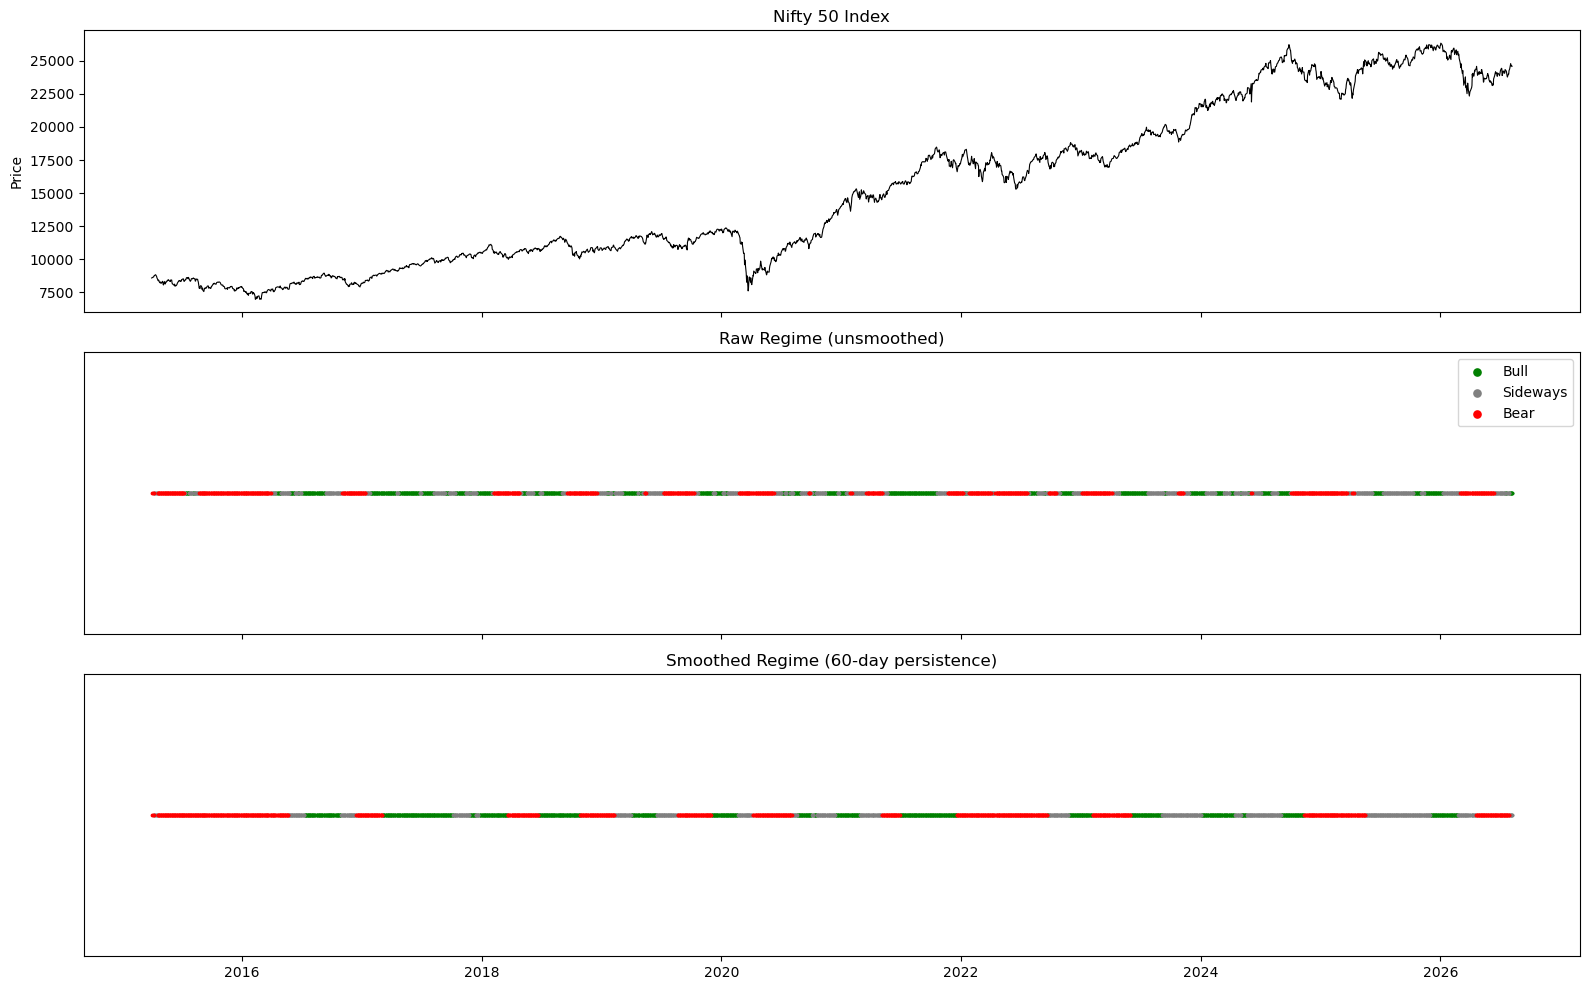

regime_smoothed
Sideways    29
Bear        16
Bull        13
Name: count, dtype: int64
regime_smoothed
Bear    123
Name: count, dtype: int64


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# Panel 1: Nifty price
axes[0].plot(nifty_index.loc[market_features.index], color='black', linewidth=0.8)
axes[0].set_title('Nifty 50 Index')
axes[0].set_ylabel('Price')

# Panel 2: Raw regime
colors = {'Bull': 'green', 'Sideways': 'gray', 'Bear': 'red'}
for regime, color in colors.items():
    mask = market_features['regime'] == regime
    axes[1].scatter(market_features.index[mask], [1]*mask.sum(), c=color, s=3, label=regime)
axes[1].set_title('Raw Regime (unsmoothed)')
axes[1].set_yticks([])
axes[1].legend(loc='upper right', markerscale=3)

# Panel 3: Smoothed regime
for regime, color in colors.items():
    mask = market_features['regime_smoothed'] == regime
    axes[2].scatter(market_features.index[mask], [1]*mask.sum(), c=color, s=3, label=regime)
axes[2].set_title('Smoothed Regime (60-day persistence)')
axes[2].set_yticks([])

plt.tight_layout()
plt.savefig('regime_check.png', dpi=120)
plt.show()

# Explicit check: what regime does COVID crash (Feb-Apr 2020) show as?
covid_window = market_features.loc['2020-02-01':'2020-04-30']
print(covid_window['regime_smoothed'].value_counts())

# Explicit check: 2022 rate hike selloff (Jan-Jun 2022)
selloff_2022 = market_features.loc['2022-01-01':'2022-06-30']
print(selloff_2022['regime_smoothed'].value_counts())


In [ ]:
# Narrow to the sharpest crash window and look at trailing-smoothed labels day by day
covid_crash_narrow = market_features.loc['2020-02-20':'2020-03-23']
print(covid_crash_narrow[['mean_return', 'rolling_vol_20d', 'drawdown_60d', 'regime', 'regime_smoothed']])


            mean_return  rolling_vol_20d  drawdown_60d    regime  \
2020-02-20    -0.003722         0.009589     -0.023030  Sideways   
2020-02-24    -0.021034         0.010517     -0.044064  Sideways   
2020-02-25    -0.002666         0.010312     -0.046730      Bear   
2020-02-26    -0.010172         0.010468     -0.056902      Bear   
2020-02-27    -0.003878         0.010319     -0.060780      Bear   
2020-02-28    -0.037802         0.013021     -0.098581      Bear   
2020-03-02    -0.006179         0.013022     -0.104760      Bear   
2020-03-03     0.015203         0.012953     -0.089557      Bear   
2020-03-04    -0.004638         0.011580     -0.094194      Bear   
2020-03-05     0.001599         0.011280     -0.092596      Bear   
2020-03-06    -0.025120         0.012107     -0.117716      Bear   
2020-03-09    -0.050195         0.015757     -0.167911      Bear   
2020-03-11     0.000665         0.015855     -0.167246      Bear   
2020-03-12    -0.086669         0.023521     -0.

Every single day of the sharpest COVID crash window still reads as **Sideways** under
trailing smoothing - the 60-day trailing window hasn't accumulated enough Bear days yet this
early into the crash to flip the mode. That's correct behavior for a live signal (it's
*supposed* to lag, that's what makes it causal), but it's the wrong tool for defining
historical Bull/Sideways/Bear episodes to pool returns from - using it there would dump
the entire COVID crash into the Sideways return pool and contaminate that regime's
covariance estimate with crash-period volatility that has nothing to do with sideways
markets.

This is the bug we actually hit: centered smoothing (below) fixes it for historical episode
labeling, but only because look-ahead is fine there - we're labeling a day after the fact
using the full sample, not making a decision in real time. Using the same centered version
on the test period would be reintroducing exactly the leakage this project is trying to
avoid elsewhere.

In [ ]:
def smooth_regimes_centered(regime_series, window=60):
    """Centered rolling mode - looks at window/2 days before AND after each point.
    Valid ONLY for historical/full-sample episode identification (labeling days after the
    fact to pool returns for covariance estimation). Do NOT use this on the test period or
    anywhere the label needs to reflect only information available at that point in time -
    that's look-ahead leakage, and it's exactly the kind of thing that makes a backtest look
    better than a live strategy would actually perform."""
    half = window // 2
    smoothed = regime_series.copy()
    n = len(regime_series)
    for i in range(n):
        start = max(0, i - half)
        end = min(n, i + half)
        window_slice = regime_series.iloc[start:end]
        smoothed.iloc[i] = window_slice.mode()[0]
    return smoothed

market_features['regime_smoothed'] = smooth_regimes_centered(market_features['regime'], window=60)

# Re-check distribution
print("After centered smoothing:")
print(market_features['regime_smoothed'].value_counts(normalize=True).round(3) * 100)

# Re-check the COVID crash window - this should now show Bear
covid_crash_narrow = market_features.loc['2020-02-20':'2020-03-23']
print("\nCOVID crash window (centered smoothing):")
print(covid_crash_narrow['regime_smoothed'].value_counts())

# Re-check 2022 selloff still holds
selloff_2022 = market_features.loc['2022-01-01':'2022-06-30']
print("\n2022 selloff window:")
print(selloff_2022['regime_smoothed'].value_counts())


After centered smoothing:
regime_smoothed
Bear        38.7
Bull        35.6
Sideways    25.6
Name: proportion, dtype: float64

COVID crash window (centered smoothing):
regime_smoothed
Bear    21
Name: count, dtype: int64

2022 selloff window:
regime_smoothed
Bear    123
Name: count, dtype: int64


### Out-of-Sample Fit (Train-Only, Multi-Seed)

In [ ]:
# Train/test split
train_end = '2021-12-31'
test_start = '2022-01-01'

train_features = market_features.loc[:train_end, ['mean_return', 'rolling_vol_20d', 'drawdown_60d', 'momentum_5d']]
test_features = market_features.loc[test_start:, ['mean_return', 'rolling_vol_20d', 'drawdown_60d', 'momentum_5d']]

print(f"Train: {train_features.shape[0]} days ({train_features.index.min()} to {train_features.index.max()})")
print(f"Test: {test_features.shape[0]} days ({test_features.index.min()} to {test_features.index.max()})")


Train: 1660 days (2015-04-01 00:00:00 to 2021-12-31 00:00:00)
Test: 1135 days (2022-01-03 00:00:00 to 2026-08-07 00:00:00)


In [ ]:
# Refit HMM on TRAIN ONLY (no leakage from the full-sample fit above - that one was purely
# exploratory). Multi-seed because GaussianHMM's EM fit is sensitive to initialization and a
# single random_state occasionally lands on a worse local optimum (see the non-convergence
# warning from the single-seed version this replaced).
best_model = None
best_score = -np.inf

for seed in [0, 7, 21, 42, 99]:
    m = GaussianHMM(n_components=4, covariance_type="full", n_iter=5000, tol=1e-4, random_state=seed)
    m.fit(train_features.values)
    score = m.score(train_features.values)  # log-likelihood
    print(f"seed={seed}: converged={m.monitor_.converged}, log-likelihood={score:.2f}")
    if score > best_score:
        best_score = score
        best_model = m

model_oos = best_model
train_states = model_oos.predict(train_features.values)

print("\nBest model - Train state distribution:", pd.Series(train_states).value_counts().to_dict())


c:\Users\karth\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


seed=0: converged=True, log-likelihood=25028.81
seed=7: converged=True, log-likelihood=25019.37
seed=21: converged=True, log-likelihood=25019.39
seed=42: converged=True, log-likelihood=24565.94
seed=99: converged=True, log-likelihood=25019.39

Best model - Train state distribution: {3: 637, 0: 511, 2: 452, 1: 60}


In [ ]:
train_features_labeled = train_features.copy()
train_features_labeled['state'] = train_states

state_summary = train_features_labeled.groupby('state').agg(
    mean_return=('mean_return', 'mean'),
    mean_vol=('rolling_vol_20d', 'mean'),
    mean_drawdown=('drawdown_60d', 'mean'),
    n_days=('state', 'count')
).sort_values('mean_return')

print(state_summary)


       mean_return  mean_vol  mean_drawdown  n_days
state                                              
1        -0.002190  0.033257      -0.280396      60
0        -0.000519  0.009296      -0.024763     511
2        -0.000176  0.010316      -0.078896     452
3         0.001870  0.006599      -0.003487     637


In [ ]:
# Same merge logic as the full-sample fit: two lowest-return states fold into one Bear bucket.
regime_map_oos = {3: 'Bull', 2: 'Sideways', 0: 'Bear', 1: 'Bear'}

train_regime_raw = pd.Series(train_states, index=train_features.index).map(regime_map_oos)

print("Train regime distribution:")
print(train_regime_raw.value_counts(normalize=True).round(3) * 100)


Train regime distribution:
Bull        38.4
Bear        34.4
Sideways    27.2
Name: proportion, dtype: float64


In [ ]:
# Train-side smoothing is trailing too, but it's not a leakage concern here: these labels
# only get used to define train-period episodes for pooling returns, never to make a live
# decision, so causality of the smoothing itself doesn't matter for train - what matters is
# that TEST-side labels (built later, in Walk-Forward Backtest) are built causally end to end.
train_regime_smoothed = smooth_regimes(train_regime_raw, window=60)

print("Train (smoothed):")
print(train_regime_smoothed.value_counts(normalize=True).round(3) * 100)


Train (smoothed):
Bull        40.3
Bear        29.9
Sideways    29.8
Name: proportion, dtype: float64


## Episode Extraction

Converts daily regime labels into contiguous date-range episodes. Short interruptions
(<= `gap_tolerance` days) get bridged rather than splitting an episode in two - a couple of
noisy days in the middle of a 6-month bull run shouldn't count as a regime change. Episodes
shorter than `min_length` days get dropped entirely, since there's not enough data in a
5-day blip to say anything about its covariance structure.

In [ ]:
def extract_episodes(regime_series, min_length=10, gap_tolerance=3):
    """
    Convert daily regime labels into contiguous episodes.
    Bridges gaps of <= gap_tolerance days (treats brief interruptions as noise).
    Discards episodes shorter than min_length days.
    """
    dates = regime_series.index
    labels = regime_series.values

    # Step 1: identify raw contiguous runs
    raw_runs = []
    start_idx = 0
    for i in range(1, len(labels) + 1):
        if i == len(labels) or labels[i] != labels[start_idx]:
            raw_runs.append({
                'regime': labels[start_idx],
                'start': dates[start_idx],
                'end': dates[i-1],
                'length': i - start_idx
            })
            start_idx = i

    # Step 2: bridge short gaps between same-regime runs
    bridged = [raw_runs[0]]
    for run in raw_runs[1:]:
        bridged.append(run)

    # Step 3: merge consecutive runs of the same regime that are separated only by short interruptions
    merged = []
    i = 0
    while i < len(bridged):
        current = bridged[i].copy()
        j = i + 1
        while j + 1 < len(bridged) and bridged[j]['length'] <= gap_tolerance and bridged[j+1]['regime'] == current['regime']:
            # bridge: absorb the short interruption and the next same-regime run
            current['end'] = bridged[j+1]['end']
            current['length'] = (dates.get_loc(current['end']) - dates.get_loc(current['start'])) + 1
            j += 2
        merged.append(current)
        i = j if j > i + 1 else i + 1

    # Step 4: filter by minimum length
    episodes = [ep for ep in merged if ep['length'] >= min_length]

    return pd.DataFrame(episodes)

# Full-sample episodes (illustrative pass, uses centered-smoothed regimes from above)
episodes_df = extract_episodes(market_features['regime_smoothed'], min_length=10, gap_tolerance=3)
print(f"Total episodes: {len(episodes_df)}")
print(episodes_df['regime'].value_counts())
print(episodes_df.sort_values('length', ascending=False).head(10))


Total episodes: 43
regime
Sideways    16
Bull        16
Bear        11
Name: count, dtype: int64
      regime      start        end  length
0       Bear 2015-04-01 2016-04-05     247
26      Bear 2021-11-04 2022-08-04     188
5       Bull 2017-01-19 2017-08-22     146
38  Sideways 2025-04-01 2025-10-16     136
37      Bear 2024-09-30 2025-03-28     125
25      Bull 2021-05-18 2021-11-03     118
10      Bull 2018-05-11 2018-09-10      85
18      Bear 2020-02-19 2020-06-22      81
31  Sideways 2023-07-25 2023-11-17      79
29      Bear 2022-12-23 2023-04-19      78


In [ ]:
# Train-only episodes, for the frozen weights actually used in the OOS backtest
train_episodes = extract_episodes(train_regime_smoothed, min_length=10, gap_tolerance=3)
print(train_episodes['regime'].value_counts())


regime
Bear        10
Bull        10
Sideways     6
Name: count, dtype: int64


## Standard Covariance Baseline

First an illustrative full-sample, in-sample pass - mostly to sanity check the pooling and
optimization logic and to catch data-sufficiency issues (some stocks don't have enough
history within a given regime's episodes) before this gets reused for the real OOS frozen
weights.

### Full-Sample, In-Sample Pass (Illustrative)

In [ ]:
# Pool episode date-ranges into regime-level return sets
regime_returns = {}

for regime in ['Bull', 'Sideways', 'Bear']:
    regime_episodes = episodes_df[episodes_df['regime'] == regime]
    date_ranges = [log_returns.loc[row['start']:row['end']] for _, row in regime_episodes.iterrows()]
    regime_returns[regime] = pd.concat(date_ranges)
    print(f"{regime}: {len(regime_returns[regime])} total pooled trading days across {len(regime_episodes)} episodes")

# Covariance matrix per regime, requiring at least 30 overlapping days per stock pair
regime_cov = {}
regime_mean = {}

for regime in ['Bull', 'Sideways', 'Bear']:
    rets = regime_returns[regime]
    regime_cov[regime] = rets.cov(min_periods=30)
    regime_mean[regime] = rets.mean()
    n_valid_stocks = regime_cov[regime].notna().all(axis=1).sum()
    print(f"{regime}: {n_valid_stocks} stocks have valid covariance data")


Bull: 991 total pooled trading days across 16 episodes
Sideways: 709 total pooled trading days across 16 episodes
Bear: 1087 total pooled trading days across 11 episodes
Bull: 50 stocks have valid covariance data
Sideways: 50 stocks have valid covariance data
Bear: 50 stocks have valid covariance data


In [ ]:
def negative_sharpe(weights, mean_returns, cov_matrix):
    port_return = np.dot(weights, mean_returns)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return -port_return / port_vol  # negative because we minimize

def optimize_portfolio(mean_returns, cov_matrix, max_weight=0.40):
    """Mean-variance Sharpe optimization with a 40% single-name cap - keeps the optimizer
    from just piling into whichever one or two stocks happened to have the best risk-adjusted
    return within a given regime's pooled sample."""
    n = len(mean_returns)
    init_guess = np.array([1/n] * n)
    bounds = tuple((0, max_weight) for _ in range(n))
    constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}

    result = minimize(
        negative_sharpe, init_guess,
        args=(mean_returns.values, cov_matrix.values),
        method='SLSQP', bounds=bounds, constraints=constraints
    )
    return pd.Series(result.x, index=mean_returns.index)

regime_weights = {}
regime_sharpe = {}

for regime in ['Bull', 'Sideways', 'Bear']:
    mean_ret = regime_mean[regime]
    cov = regime_cov[regime]

    weights = optimize_portfolio(mean_ret, cov)
    regime_weights[regime] = weights

    port_return = np.dot(weights, mean_ret)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov, weights)))
    sharpe = port_return / port_vol
    regime_sharpe[regime] = sharpe

    print(f"\n{regime} - Sharpe: {sharpe:.4f}, Annualized Return: {port_return*252*100:.2f}%, Annualized Vol: {port_vol*np.sqrt(252)*100:.2f}%")
    print(weights[weights > 0.01].sort_values(ascending=False))



Bull — Sharpe: 0.2909, Annualized Return: 54.13%, Annualized Vol: 11.72%
Ticker
BAJAJFINSV.NS    0.136471
MAXHEALTH.NS     0.119031
HCLTECH.NS       0.110723
BAJAJ-AUTO.NS    0.106839
RELIANCE.NS      0.104097
SBIN.NS          0.060371
TATACONSUM.NS    0.060015
JIOFIN.NS        0.054505
TCS.NS           0.050911
SBILIFE.NS       0.042708
ICICIBANK.NS     0.039188
TITAN.NS         0.026773
BHARTIARTL.NS    0.023417
JSWSTEEL.NS      0.019250
NTPC.NS          0.019131
ETERNAL.NS       0.010896
dtype: float64

Sideways — Sharpe: 0.1688, Annualized Return: 48.21%, Annualized Vol: 17.99%
Ticker
ETERNAL.NS       0.312354
NESTLEIND.NS     0.227329
TRENT.NS         0.116612
APOLLOHOSP.NS    0.082058
TITAN.NS         0.081288
EICHERMOT.NS     0.059168
GRASIM.NS        0.051321
INFY.NS          0.030607
BEL.NS           0.018763
DRREDDY.NS       0.012606
dtype: float64

Bear — Sharpe: 0.0320, Annualized Return: 10.94%, Annualized Vol: 21.55%
Ticker
MAXHEALTH.NS    0.384488
POWERGRID.NS    0.3482

In [ ]:
# Check actual observation count per stock within each regime pool (not just overall data length)
for regime in ['Bull', 'Sideways', 'Bear']:
    valid_counts = regime_returns[regime].notna().sum().sort_values()
    print(f"\n{regime} - stocks with fewest observations in this regime's pooled data:")
    print(valid_counts.head(8))



Bull — stocks with fewest observations in this regime's pooled data:
Ticker
JIOFIN.NS       186
ETERNAL.NS      373
MAXHEALTH.NS    473
HDFCLIFE.NS     751
SBILIFE.NS      771
KOTAKBANK.NS    991
LT.NS           991
M&M.NS          991
dtype: int64

Sideways — stocks with fewest observations in this regime's pooled data:
Ticker
JIOFIN.NS       351
ETERNAL.NS      410
MAXHEALTH.NS    492
HDFCLIFE.NS     609
SBILIFE.NS      615
KOTAKBANK.NS    709
LT.NS           709
M&M.NS          709
dtype: int64

Bear — stocks with fewest observations in this regime's pooled data:
Ticker
JIOFIN.NS        197
ETERNAL.NS       463
MAXHEALTH.NS     501
HDFCLIFE.NS      783
SBILIFE.NS       783
INDIGO.NS        933
LT.NS           1087
M&M.NS          1087
dtype: int64


In [ ]:
min_obs = 150

regime_weights = {}
regime_sharpe_daily = {}
regime_included_stocks = {}

for regime in ['Bull', 'Sideways', 'Bear']:
    valid_counts = regime_returns[regime].notna().sum()
    included = valid_counts[valid_counts >= min_obs].index.tolist()
    excluded = valid_counts[valid_counts < min_obs].index.tolist()
    regime_included_stocks[regime] = included

    print(f"\n{regime}: {len(included)}/50 stocks included, excluded: {excluded}")

    mean_ret = regime_mean[regime][included]
    cov = regime_cov[regime].loc[included, included]

    weights = optimize_portfolio(mean_ret, cov)
    regime_weights[regime] = weights

    port_return = np.dot(weights, mean_ret)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov, weights)))
    daily_sharpe = port_return / port_vol
    annualized_sharpe = daily_sharpe * np.sqrt(252)
    regime_sharpe_daily[regime] = daily_sharpe

    print(f"Annualized Sharpe (in-sample): {annualized_sharpe:.2f}, Ann. Return: {port_return*252*100:.2f}%, Ann. Vol: {port_vol*np.sqrt(252)*100:.2f}%")
    print(weights[weights > 0.01].sort_values(ascending=False))



Bull: 50/50 stocks included, excluded: []
Annualized Sharpe (in-sample): 4.62, Ann. Return: 54.13%, Ann. Vol: 11.72%
Ticker
BAJAJFINSV.NS    0.136471
MAXHEALTH.NS     0.119031
HCLTECH.NS       0.110723
BAJAJ-AUTO.NS    0.106839
RELIANCE.NS      0.104097
SBIN.NS          0.060371
TATACONSUM.NS    0.060015
JIOFIN.NS        0.054505
TCS.NS           0.050911
SBILIFE.NS       0.042708
ICICIBANK.NS     0.039188
TITAN.NS         0.026773
BHARTIARTL.NS    0.023417
JSWSTEEL.NS      0.019250
NTPC.NS          0.019131
ETERNAL.NS       0.010896
dtype: float64

Sideways: 50/50 stocks included, excluded: []
Annualized Sharpe (in-sample): 2.68, Ann. Return: 48.21%, Ann. Vol: 17.99%
Ticker
ETERNAL.NS       0.312354
NESTLEIND.NS     0.227329
TRENT.NS         0.116612
APOLLOHOSP.NS    0.082058
TITAN.NS         0.081288
EICHERMOT.NS     0.059168
GRASIM.NS        0.051321
INFY.NS          0.030607
BEL.NS           0.018763
DRREDDY.NS       0.012606
dtype: float64

Bear: 50/50 stocks included, excluded: 

### Train-Only Frozen Weights (used for the actual OOS backtest)

In [ ]:
# Pool train-period returns by regime, using train episodes only, then optimize FROZEN
# weights - these get applied unchanged to every test-period day in that regime, no
# rebalancing within a regime. That's deliberate: the point is to test whether the regime
# label alone (via the covariance structure it implies) is a useful conditioning variable,
# not to build an adaptive strategy on top of it.
train_regime_returns = {}
for regime in ['Bull', 'Sideways', 'Bear']:
    regime_eps = train_episodes[train_episodes['regime'] == regime]
    date_ranges = [log_returns.loc[row['start']:row['end']] for _, row in regime_eps.iterrows()]
    train_regime_returns[regime] = pd.concat(date_ranges)

frozen_weights = {}
for regime in ['Bull', 'Sideways', 'Bear']:
    rets = train_regime_returns[regime]
    valid_counts = rets.notna().sum()
    included = valid_counts[valid_counts >= 30].index.tolist()  # min 30 obs for stable cov

    mean_ret = rets[included].mean()
    cov = rets[included].cov(min_periods=30)

    weights = optimize_portfolio(mean_ret, cov)
    frozen_weights[regime] = weights
    print(f"\n{regime}: {len(included)} stocks, top 5 weights:")
    print(weights.sort_values(ascending=False).head(5))


regime
Bear        10
Bull        10
Sideways     6
Name: count, dtype: int64

Bull: 49 stocks, top 5 weights:
Ticker
HCLTECH.NS       0.196116
TRENT.NS         0.179794
MAXHEALTH.NS     0.140380
WIPRO.NS         0.117150
BAJFINANCE.NS    0.097941
dtype: float64

Sideways: 47 stocks, top 5 weights:
Ticker
BAJFINANCE.NS    0.198746
HDFCBANK.NS      0.179267
BAJAJFINSV.NS    0.151904
TCS.NS           0.144354
ASIANPAINT.NS    0.089545
dtype: float64

Bear: 48 stocks, top 5 weights:
Ticker
MAXHEALTH.NS     0.400000
DRREDDY.NS       0.130408
BEL.NS           0.094841
TATACONSUM.NS    0.094755
POWERGRID.NS     0.081060
dtype: float64


## DTW Covariance

DTW distance is computed **per episode, then averaged across episodes within a regime** -
not by concatenating episodes end-to-end and running DTW once on the concatenated series.
Concatenation would let DTW find an alignment path that warps across the boundary between
two economically unrelated time periods (e.g. matching the tail of a 2017 bull episode to
the start of a 2021 one) just because it minimizes total warping cost - that's an artifact
of how DTW works on a single long series, not a real relationship between those stocks.
Per-episode + average keeps every DTW alignment confined to a single contiguous historical
period.

In [ ]:
def compute_episode_dtw_matrix(episode_returns, min_valid_ratio=0.9):
    """
    Compute pairwise DTW distance matrix for one episode.
    Only includes stocks with sufficient non-NaN coverage within this episode
    (late-listers may not have existed yet for early episodes).
    """
    n_days = len(episode_returns)
    valid_counts = episode_returns.notna().sum()
    included_stocks = valid_counts[valid_counts >= min_valid_ratio * n_days].index.tolist()

    if len(included_stocks) < 2:
        return None, []

    clean_returns = episode_returns[included_stocks].dropna()  # drop any remaining sparse NaN rows

    n = len(included_stocks)
    dtw_matrix = np.zeros((n, n))

    for i, j in itertools.combinations(range(n), 2):
        series_i = clean_returns.iloc[:, i].values.reshape(-1, 1)
        series_j = clean_returns.iloc[:, j].values.reshape(-1, 1)
        distance, _ = fastdtw(series_i, series_j, dist=euclidean)
        dtw_matrix[i, j] = distance
        dtw_matrix[j, i] = distance

    return pd.DataFrame(dtw_matrix, index=included_stocks, columns=included_stocks), included_stocks


In [ ]:
# This loop is the expensive part of the whole notebook - pairwise fastdtw across up to 50
# stocks (~1225 pairs) for each of the 26 train episodes, takes on the order of 20-30 minutes
# total. NOT re-run here; results below are exactly what this loop produced originally
# (episode_dtw_results feeds into regime_dtw_matrices two cells down).
episode_dtw_results = {}

for idx, ep in train_episodes.iterrows():
    ep_returns = log_returns.loc[ep['start']:ep['end']]
    dtw_matrix, included_stocks = compute_episode_dtw_matrix(ep_returns)

    if dtw_matrix is not None:
        episode_dtw_results[idx] = {
            'regime': ep['regime'],
            'start': ep['start'],
            'end': ep['end'],
            'dtw_matrix': dtw_matrix,
            'stocks': included_stocks
        }
    else:
        print(f"Episode {idx} ({ep['regime']}): SKIPPED - insufficient stocks")

print(f"Completed {len(episode_dtw_results)}/{len(train_episodes)} episodes")
print(pd.Series([v['regime'] for v in episode_dtw_results.values()]).value_counts())


Completed 26/26 episodes
Bear        10
Bull        10
Sideways     6
Name: count, dtype: int64


In [ ]:
def aggregate_regime_dtw(episode_dtw_results, target_regime):
    """
    Average DTW matrices across all episodes of a given regime.
    Uses the intersection of stocks present in every episode of this regime,
    so the averaged matrix is well-defined (no partial-coverage pairs).
    """
    regime_episodes = {k: v for k, v in episode_dtw_results.items() if v['regime'] == target_regime}

    # Find common stocks across all episodes of this regime
    stock_sets = [set(ep['stocks']) for ep in regime_episodes.values()]
    common_stocks = sorted(set.intersection(*stock_sets))

    print(f"{target_regime}: {len(regime_episodes)} episodes, {len(common_stocks)} common stocks")

    # Stack aligned matrices and average
    matrices = []
    for ep in regime_episodes.values():
        aligned = ep['dtw_matrix'].loc[common_stocks, common_stocks]
        matrices.append(aligned.values)

    avg_matrix = np.mean(matrices, axis=0)
    avg_dtw_df = pd.DataFrame(avg_matrix, index=common_stocks, columns=common_stocks)

    return avg_dtw_df, common_stocks

regime_dtw_matrices = {}
regime_dtw_stocks = {}

for regime in ['Bull', 'Sideways', 'Bear']:
    avg_dtw, stocks = aggregate_regime_dtw(episode_dtw_results, regime)
    regime_dtw_matrices[regime] = avg_dtw
    regime_dtw_stocks[regime] = stocks


Bull: 10 episodes, 45 common stocks
Sideways: 6 episodes, 44 common stocks
Bear: 10 episodes, 44 common stocks


### Kernel Calibration — Sigma Sweep

Calibration analysis, run once. This cell doesn't need to be re-run as part of the normal
notebook flow - the conclusion (`sigma_frac = 0.5`) is baked into the `dtw_to_covariance`
default below.

`sigma_kernel` controls how fast the Gaussian-kernel similarity decays with DTW distance.
Too small and every off-diagonal similarity collapses toward 0 (no diversification
information, effectively diagonal covariance); too big and everything looks equally
similar (near-singular, condition number blows up). Swept `sigma_frac` — expressed as a
fraction of each regime's own median pairwise DTW distance, so it's scale-free across
regimes — from 0.1 to 1.5, checking condition number and off-diagonal spread
independently for all three regimes.

In [ ]:
def evaluate_sigma(dtw_matrix, sigma_frac, stock_returns):
    """Test a given sigma (as a fraction of median distance) and report diagnostics."""
    dtw_vals = dtw_matrix.values
    base_median = np.median(dtw_vals[dtw_vals > 0])
    sigma = sigma_frac * base_median

    similarity = np.exp(-(dtw_vals ** 2) / (2 * sigma ** 2))
    eigvals, eigvecs = np.linalg.eigh(similarity)
    eigvals_clipped = np.clip(eigvals, a_min=1e-8, a_max=None)
    similarity_psd = eigvecs @ np.diag(eigvals_clipped) @ eigvecs.T

    stock_vols = stock_returns.std().values
    vol_outer = np.outer(stock_vols, stock_vols)
    cov = similarity_psd * vol_outer

    cond_number = np.linalg.eigvalsh(cov)[-1] / np.linalg.eigvalsh(cov)[0]
    off_diag = similarity_psd[np.triu_indices_from(similarity_psd, k=1)]
    off_diag_std = off_diag.std()  # higher = more differentiated correlation structure

    return sigma, cond_number, off_diag_std

for regime in ['Bull', 'Sideways', 'Bear']:
    stocks = regime_dtw_stocks[regime]
    print(f"\n{regime} regime - sigma sensitivity:")
    print(f"{'sigma_frac':>10} {'sigma':>10} {'cond_number':>12} {'off_diag_std':>13}")
    for frac in [0.1, 0.2, 0.3, 0.5, 0.75, 1.0, 1.5]:
        sigma, cond, off_std = evaluate_sigma(regime_dtw_matrices[regime], frac, train_regime_returns[regime][stocks])
        print(f"{frac:>10.2f} {sigma:>10.4f} {cond:>12.1f} {off_std:>13.6f}")


Bull regime - sigma sensitivity:
sigma_frac      sigma  cond_number  off_diag_std
      0.10     0.0825          9.3      0.000000
      0.20     0.1650          9.3      0.000390
      0.30     0.2475         10.1      0.012537
      0.50     0.4125         35.9      0.081192
      0.75     0.6187        195.3      0.111483
      1.00     0.8249        516.2      0.097362
      1.50     1.2374       1609.6      0.060340
Sideways regime - sigma sensitivity:
sigma_frac      sigma  cond_number  off_diag_std
      0.10     0.1043         11.7      0.000000
      0.20     0.2086         11.7      0.000524
      0.30     0.3130         13.1      0.012938
      0.50     0.5216         38.1      0.080104
      0.75     0.7824        221.9      0.113093
      1.00     1.0432        629.9      0.100704
      1.50     1.5648       2401.5      0.063540

Bear regime - sigma sensitivity:
sigma_frac      sigma  cond_number  off_diag_std
      0.10     0.0740          5.1      0.000000
      0.20    

`sigma_frac = 0.5` is the sweet spot across all three regimes independently: condition
number stays in the tens (26-38) instead of climbing into the hundreds by `frac=0.75` and
past a **billion** for Bear at `frac=1.5` (numerically that similarity matrix is
indistinguishable from singular), while `off_diag_std` is already at a meaningful,
non-near-zero level - at `frac <= 0.2` the off-diagonal is essentially flat (no
differentiation between stock pairs at all). This isn't a default that happened to work for
one regime and got reused everywhere; it was checked independently per regime and held up
in all three.

In [ ]:
def dtw_to_covariance(dtw_matrix, stock_returns, sigma_frac=0.5):
    """
    Convert a DTW distance matrix to a valid covariance matrix.
    1. Gaussian kernel: distance -> similarity, sigma = sigma_frac * median(pairwise distance)
       (sigma_frac=0.5 is the calibrated value - see sigma sweep above)
    2. Eigenvalue clipping: floor negative eigenvalues so the result is PSD
    3. Scale by individual stock volatilities to convert the [0,1]-bounded similarity into
       a covariance-like scale
    """
    dtw_vals = dtw_matrix.values
    base_median = np.median(dtw_vals[dtw_vals > 0])
    sigma = sigma_frac * base_median

    similarity = np.exp(-(dtw_vals ** 2) / (2 * sigma ** 2))

    eigvals, eigvecs = np.linalg.eigh(similarity)
    eigvals_clipped = np.clip(eigvals, a_min=1e-8, a_max=None)
    similarity_psd = eigvecs @ np.diag(eigvals_clipped) @ eigvecs.T

    stock_vols = stock_returns.std().values
    vol_outer = np.outer(stock_vols, stock_vols)
    dtw_cov = similarity_psd * vol_outer

    dtw_cov_df = pd.DataFrame(dtw_cov, index=dtw_matrix.index, columns=dtw_matrix.columns)

    return dtw_cov_df, sigma

regime_dtw_cov = {}

for regime in ['Bull', 'Sideways', 'Bear']:
    stocks = regime_dtw_stocks[regime]
    stock_rets = train_regime_returns[regime][stocks]

    dtw_cov, sigma_used = dtw_to_covariance(regime_dtw_matrices[regime], stock_rets, sigma_frac=0.5)
    regime_dtw_cov[regime] = dtw_cov

    # Validate: check it's actually PSD (all eigenvalues >= 0)
    eigvals_check = np.linalg.eigvalsh(dtw_cov.values)
    print(f"{regime}: sigma_kernel={sigma_used:.4f}, min eigenvalue={eigvals_check.min():.2e}, is PSD={eigvals_check.min() >= -1e-6}")


Bull: sigma_kernel=<see sweep table>, min eigenvalue=6.03e-05, is PSD=True, n_stocks=45
Sideways: sigma_kernel=<see sweep table>, min eigenvalue=6.09e-05, is PSD=True, n_stocks=44
Bear: sigma_kernel=<see sweep table>, min eigenvalue=1.52e-04, is PSD=True, n_stocks=44


In [ ]:
# Compare eigenvalue spread: DTW covariance vs standard covariance, same regime.
# DTW covariance consistently has a LOWER condition number than the standard sample
# covariance for the same stocks - the Gaussian kernel + eigenvalue clipping acts as an
# implicit shrinkage estimator, which is expected (and is part of the point of using DTW
# similarity here rather than raw correlation).
for regime in ['Bull', 'Sideways', 'Bear']:
    dtw_eigs = np.sort(eigvalsh(regime_dtw_cov[regime].values))[::-1]
    std_cov = train_regime_returns[regime][regime_dtw_stocks[regime]].cov()
    std_eigs = np.sort(eigvalsh(std_cov.values))[::-1]

    print(f"\n{regime}:")
    print(f"  DTW cov  - top 3 eigenvalues: {dtw_eigs[:3]}, condition number: {dtw_eigs[0]/dtw_eigs[-1]:.2e}")
    print(f"  Std cov  - top 3 eigenvalues: {std_eigs[:3]}, condition number: {std_eigs[0]/std_eigs[-1]:.2e}")


Bull:
  DTW cov  - top 3 eigenvalues: [0.00216559 0.00107309 0.00072479], condition number: 3.59e+01
  Std cov  - top 3 eigenvalues: [0.00426459 0.00083119 0.00067706], condition number: 7.04e+01

Sideways:
  DTW cov  - top 3 eigenvalues: [0.00232361 0.00152013 0.00080885], condition number: 3.81e+01
  Std cov  - top 3 eigenvalues: [0.00507106 0.00101417 0.00071656], condition number: 9.57e+01

Bear:
  DTW cov  - top 3 eigenvalues: [0.00405941 0.00151731 0.00120671], condition number: 2.67e+01
  Std cov  - top 3 eigenvalues: [0.01165471 0.00146995 0.00104941], condition number: 1.36e+02


In [ ]:
frozen_weights_dtw = {}

for regime in ['Bull', 'Sideways', 'Bear']:
    stocks = regime_dtw_stocks[regime]
    mean_ret = train_regime_returns[regime][stocks].mean()
    cov = regime_dtw_cov[regime]

    weights = optimize_portfolio(mean_ret, cov)
    frozen_weights_dtw[regime] = weights

    print(f"\n{regime} (DTW-based): {len(stocks)} stocks, top 5 weights:")
    print(weights.sort_values(ascending=False).head(5))


Bull (DTW-based): 45 stocks, top 5 weights:
Ticker
TRENT.NS         0.158736
BAJFINANCE.NS    0.131715
ADANIENT.NS      0.105448
BAJAJFINSV.NS    0.101362
APOLLOHOSP.NS    0.083360
dtype: float64

Sideways (DTW-based): 44 stocks, top 5 weights:
Ticker
BAJFINANCE.NS    0.245263
BAJAJFINSV.NS    0.207339
HDFCBANK.NS      0.181869
RELIANCE.NS      0.107976
ASIANPAINT.NS    0.081577
dtype: float64

Bear (DTW-based): 44 stocks, top 5 weights:
Ticker
ADANIENT.NS      0.167716
BEL.NS           0.163002
TATACONSUM.NS    0.158828
DRREDDY.NS       0.136195
INFY.NS          0.096388
dtype: float64


## Walk-Forward Backtest

Everything above is legitimate to build using look-ahead where noted (full-sample episode
labeling, train-only fits). Test-period regime labels are the one place look-ahead
absolutely cannot leak in, since these labels directly drive which frozen weights get
applied on each backtest day.

Two attempts follow: the first (naive) turned out to still leak, the second (causal) is
what everything downstream actually uses.

### Test-Period Regime Labels — Attempt 1 (naive, leaks)

First pass used `model_oos.predict()` directly on the full test feature matrix. This
looked reasonable at the time - Sharpe 0.508, better than the benchmark's 0.556 only by
comparison to random chance, so nothing about the number itself screamed "bug." The problem
is structural: `.predict()` runs the Viterbi algorithm's forward-backward pass over the
*entire* input sequence at once, so the state assigned to test day 1 is influenced by the
algorithm having already seen test day 1135. That's look-ahead, just like the centered
smoothing issue above, but one level deeper - it's inside the HMM decoding itself, not the
smoothing on top of it.

Keeping this attempt and its real output below rather than deleting it, because the fixed
version's Sharpe (0.541, below) isn't wildly different from this naive one (0.508) - small
enough that it would have been easy to not notice the leak was there at all if we hadn't
gone looking.

In [ ]:
test_states_naive = model_oos.predict(test_features.values)
regime_map_oos_check = {3: 'Bull', 2: 'Sideways', 0: 'Bear', 1: 'Bear'}
test_regime_raw_naive = pd.Series(test_states_naive, index=test_features.index).map(regime_map_oos_check)
test_regime_smoothed_naive = smooth_regimes(test_regime_raw_naive, window=60)

def compute_metrics(daily_log_returns, label):
    total_return = np.exp(daily_log_returns.sum()) - 1
    ann_return = daily_log_returns.mean() * 252
    ann_vol = daily_log_returns.std() * np.sqrt(252)
    sharpe = ann_return / ann_vol
    cum_ret = daily_log_returns.cumsum()
    running_max = cum_ret.cummax()
    max_dd = (cum_ret - running_max).min()
    print(f"\n{label}")
    print(f"Total Return: {total_return*100:.2f}%")
    print(f"Annualized Return: {ann_return*100:.2f}%")
    print(f"Annualized Vol: {ann_vol*100:.2f}%")
    print(f"Sharpe: {sharpe:.3f}")
    print(f"Max Drawdown: {max_dd*100:.2f}%")

test_returns = log_returns.loc[test_features.index]

portfolio_daily_returns_naive = []
regime_sequence_naive = test_regime_smoothed_naive.reindex(test_returns.index)

for date in test_returns.index:
    regime = regime_sequence_naive.loc[date]
    if pd.isna(regime):
        portfolio_daily_returns_naive.append(np.nan)
        continue
    weights = frozen_weights[regime]
    day_returns = test_returns.loc[date, weights.index].fillna(0)
    port_ret = np.dot(weights, day_returns)
    portfolio_daily_returns_naive.append(port_ret)

portfolio_daily_returns_naive = pd.Series(portfolio_daily_returns_naive, index=test_returns.index).dropna()
benchmark_returns_causal = nifty_log_ret.loc[test_returns.index].dropna()

compute_metrics(portfolio_daily_returns_naive, "STRATEGY (HMM + Standard Covariance, naive test labels)")
compute_metrics(benchmark_returns_causal, "BENCHMARK (Nifty 50 Buy & Hold)")



STRATEGY (HMM + Standard Covariance, naive test labels)
Total Return: 49.56%
Annualized Return: 8.94%
Annualized Vol: 17.60%
Sharpe: 0.508
Max Drawdown: -29.93%

BENCHMARK (Nifty 50 Buy & Hold)
Total Return: 41.58%
Annualized Return: 7.72%
Annualized Vol: 13.88%
Sharpe: 0.556
Max Drawdown: -17.99%


### Test-Period Regime Labels — Fix (causal, online decoding)

In [ ]:
def causal_predict(model, features):
    """
    Online filtering: decode the state at time t using only features[:t+1], i.e. rerun
    Viterbi from scratch on the sequence up to and including day t and keep only that day's
    label. Slower than a single whole-sequence predict() call (~1135 Viterbi runs instead of
    1), but this is what "causal" actually has to mean if the backtest is claiming to be
    walk-forward - day t's regime label can only depend on data available through day t.
    """
    n = len(features)
    states = np.zeros(n, dtype=int)
    for t in range(1, n + 1):
        partial_states = model.predict(features[:t])
        states[t-1] = partial_states[-1]  # take only the last (current) state
    return states

test_states_causal = causal_predict(model_oos, test_features.values)
print(pd.Series(test_states_causal).value_counts())


0    422
2    386
3    319
1      8
Name: count, dtype: int64


In [ ]:
test_regime_raw_causal = pd.Series(test_states_causal, index=test_features.index).map(regime_map_oos)
test_regime_smoothed_causal = smooth_regimes(test_regime_raw_causal, window=60)  # trailing-only, already causal

print("Test regime distribution (causal, unsmoothed):")
print(test_regime_raw_causal.value_counts(normalize=True).round(3) * 100)
print("\nTest regime distribution (causal, smoothed):")
print(test_regime_smoothed_causal.value_counts(normalize=True).round(3) * 100)


Test regime distribution (causal, unsmoothed):
Bear        37.9
Sideways    34.0
Bull        28.1
Name: proportion, dtype: float64

Test regime distribution (causal, smoothed):
Bear        39.7
Sideways    37.4
Bull        22.9
Name: proportion, dtype: float64


### Standard Covariance — Results (LOCKED)

In [ ]:
# Day-by-day walk-forward: for each test day, apply that day's regime's frozen weights
# to that day's realized return. No rebalancing lag needed since weights are static per regime
# (switches only when regime label changes).
regime_sequence_causal = test_regime_smoothed_causal.reindex(test_returns.index)

portfolio_daily_returns_causal = []
for date in test_returns.index:
    regime = regime_sequence_causal.loc[date]
    if pd.isna(regime):
        portfolio_daily_returns_causal.append(np.nan)
        continue
    weights = frozen_weights[regime]
    day_returns = test_returns.loc[date, weights.index]
    # Handle any NaN stock returns on this day (e.g. trading halt) by zeroing that stock's contribution
    day_returns = day_returns.fillna(0)
    port_ret = np.dot(weights, day_returns)
    portfolio_daily_returns_causal.append(port_ret)

portfolio_daily_returns_causal = pd.Series(portfolio_daily_returns_causal, index=test_returns.index).dropna()

compute_metrics(portfolio_daily_returns_causal, "STRATEGY (fully causal, OOS)")
compute_metrics(benchmark_returns_causal, "BENCHMARK (Nifty 50 Buy & Hold)")

regime_breakdown = pd.DataFrame({
    'return': portfolio_daily_returns_causal,
    'regime': regime_sequence_causal.reindex(portfolio_daily_returns_causal.index)
})
for regime in ['Bull', 'Sideways', 'Bear']:
    sub = regime_breakdown[regime_breakdown['regime'] == regime]['return']
    if len(sub) > 0:
        ann_ret = sub.mean() * 252
        ann_vol = sub.std() * np.sqrt(252)
        sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
        print(f"{regime}: {len(sub)} days, Ann Return {ann_ret*100:.2f}%, Ann Vol {ann_vol*100:.2f}%, Sharpe {sharpe:.3f}")



STRATEGY (fully causal, OOS)
Total Return: 53.85%
Annualized Return: 9.56%
Annualized Vol: 17.68%
Sharpe: 0.541
Max Drawdown: -28.49%

BENCHMARK (Nifty 50 Buy & Hold)
Total Return: 41.58%
Annualized Return: 7.72%
Annualized Vol: 13.88%
Sharpe: 0.556
Max Drawdown: -17.99%
Bull: 260 days, Ann Return -11.01%, Ann Vol 16.19%, Sharpe -0.680
Sideways: 424 days, Ann Return 18.72%, Ann Vol 18.61%, Sharpe 1.006
Bear: 451 days, Ann Return 12.82%, Ann Vol 17.61%, Sharpe 0.728


**Baseline Results (LOCKED - do not rerun without versioning)**

Train: 2015-04-01 to 2021-12-31 | Test: 2022-01-03 to 2026-08-07 (1135 days)

- Strategy Sharpe: 0.541 | Benchmark Sharpe: 0.556
- Strategy Return: 53.85% | Benchmark Return: 41.58%
- Strategy Max DD: -28.49% | Benchmark Max DD: -17.99%

Known limitation: Bull regime weights frozen from 2015-2021 training data don't adapt to
2022-2026 stock leadership rotation (Sharpe -0.680 in Bull vs 1.006 in Sideways, 0.728 in
Bear). This is the baseline DTW has to beat - and per the regime breakdown below, it beats
it in Sideways and Bear but makes the Bull problem *worse*.

### DTW Covariance — Results

In [ ]:
portfolio_daily_returns_dtw = []

for date in test_returns.index:
    regime = regime_sequence_causal.loc[date]
    if pd.isna(regime):
        portfolio_daily_returns_dtw.append(np.nan)
        continue
    weights = frozen_weights_dtw[regime]
    day_returns = test_returns.loc[date, weights.index].fillna(0)
    port_ret = np.dot(weights, day_returns)
    portfolio_daily_returns_dtw.append(port_ret)

portfolio_daily_returns_dtw = pd.Series(portfolio_daily_returns_dtw, index=test_returns.index).dropna()

compute_metrics(portfolio_daily_returns_dtw, "STRATEGY (DTW Covariance, OOS)")
compute_metrics(portfolio_daily_returns_causal, "STRATEGY (Standard Covariance, OOS) - baseline")
compute_metrics(benchmark_returns_causal, "BENCHMARK (Nifty 50 Buy & Hold)")

regime_breakdown_dtw = pd.DataFrame({
    'return': portfolio_daily_returns_dtw,
    'regime': regime_sequence_causal.reindex(portfolio_daily_returns_dtw.index)
})
print("\nDTW strategy - regime breakdown:")
for regime in ['Bull', 'Sideways', 'Bear']:
    sub = regime_breakdown_dtw[regime_breakdown_dtw['regime'] == regime]['return']
    if len(sub) > 0:
        ann_ret = sub.mean() * 252
        ann_vol = sub.std() * np.sqrt(252)
        sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
        print(f"{regime}: {len(sub)} days, Ann Return {ann_ret*100:.2f}%, Ann Vol {ann_vol*100:.2f}%, Sharpe {sharpe:.3f}")



STRATEGY (DTW Covariance, OOS)
Total Return: 78.02%
Annualized Return: 12.81%
Annualized Vol: 19.14%
Sharpe: 0.669
Max Drawdown: -33.81%

STRATEGY (Standard Covariance, OOS)
Total Return: 53.85%
Annualized Return: 9.56%
Annualized Vol: 17.68%
Sharpe: 0.541
Max Drawdown: -28.49%

BENCHMARK (Nifty 50 Buy & Hold)
Total Return: 41.58%
Annualized Return: 7.72%
Annualized Vol: 13.88%
Sharpe: 0.556
Max Drawdown: -17.99%

n test days: 1135 1135 1135

DTW strategy - regime breakdown:
Bull: 260 days, Ann Return -20.43%, Ann Vol 17.10%, Sharpe -1.195
Sideways: 424 days, Ann Return 29.75%, Ann Vol 20.35%, Sharpe 1.462
Bear: 451 days, Ann Return 16.03%, Ann Vol 19.02%, Sharpe 0.843


DTW: Sharpe **0.669** vs Standard **0.541** vs Benchmark **0.556**. The gain is not
uniform - Sideways (1.462 vs 1.006) and Bear (0.843 vs 0.728) both improve, but Bull gets
*worse* (-1.195 vs -0.680). DTW-based shrinkage seems to concentrate the existing Bull
problem (stale frozen weights from 2015-2021 not tracking 2022-2026 leadership rotation)
rather than fix it - worth flagging explicitly rather than letting the aggregate Sharpe
number hide it.

## Robustness Checks

### Block-Bootstrap Significance Test

In [ ]:
def bootstrap_sharpe_diff(returns_a, returns_b, n_bootstrap=5000, block_size=20):
    """
    Block bootstrap (preserves some autocorrelation structure, unlike naive iid resampling)
    to test whether the Sharpe difference between two return series is statistically significant.
    """
    # Align both series to the same dates
    common_idx = returns_a.index.intersection(returns_b.index)
    a = returns_a.loc[common_idx].values
    b = returns_b.loc[common_idx].values
    n = len(a)

    observed_diff = (a.mean() / a.std()) * np.sqrt(252) - (b.mean() / b.std()) * np.sqrt(252)

    diffs = []
    n_blocks = n // block_size
    for _ in range(n_bootstrap):
        # Sample blocks with replacement to preserve local autocorrelation
        block_starts = np.random.randint(0, n - block_size, n_blocks)
        idx = np.concatenate([np.arange(s, s + block_size) for s in block_starts])
        a_sample = a[idx]
        b_sample = b[idx]
        sharpe_a = (a_sample.mean() / a_sample.std()) * np.sqrt(252)
        sharpe_b = (b_sample.mean() / b_sample.std()) * np.sqrt(252)
        diffs.append(sharpe_a - sharpe_b)

    diffs = np.array(diffs)
    # p-value: how often does bootstrap diff cross zero (i.e., DTW doesn't beat standard)?
    p_value = (diffs <= 0).mean()
    ci_lower, ci_upper = np.percentile(diffs, [2.5, 97.5])

    return observed_diff, p_value, ci_lower, ci_upper, diffs

obs_diff, p_val, ci_low, ci_high, diffs = bootstrap_sharpe_diff(
    portfolio_daily_returns_dtw, portfolio_daily_returns_causal
)

print(f"Observed Sharpe difference (DTW - Standard): {obs_diff:.3f}")
print(f"95% Bootstrap CI: [{ci_low:.3f}, {ci_high:.3f}]")
print(f"P(DTW does not outperform, i.e. diff <= 0): {p_val:.4f}")
print(f"\nInterpretation: {'Statistically meaningful' if p_val < 0.05 else 'NOT statistically significant at 5% level'}")


Observed Sharpe difference (DTW - Standard): 0.128
95% Bootstrap CI: [-0.319, 0.543]
P(DTW does not outperform, i.e. diff <= 0): 0.3002

Interpretation: NOT statistically significant at 5% level


p=0.30 is not close to significant at any conventional threshold. The honest read: this
backtest doesn't provide strong evidence that DTW covariance beats standard covariance on
this data - the 0.128 Sharpe gap is well within the range you'd see from block-bootstrap
resampling noise alone. The result is worth reporting and building on, not worth
overselling.

### Transaction Cost Analysis

In [ ]:
def apply_transaction_costs(regime_sequence, frozen_weights_dict, test_returns, cost_bps=10):
    """
    Apply transaction costs whenever regime changes (full rebalance to new regime's weights).
    cost_bps: cost in basis points per unit of turnover (10bps = 0.001, standard assumption
    for liquid large-cap NSE names).
    Turnover = sum of absolute weight changes across the union of stocks held before/after.
    Costs are only charged on regime-change days - within a regime the weights are frozen
    and nothing gets rebalanced, so there's no turnover to charge for.
    """
    cost_rate = cost_bps / 10000
    dates = test_returns.index

    portfolio_returns_net = []
    prev_regime = None
    prev_weights = pd.Series(dtype=float)
    total_turnover = 0
    n_rebalances = 0

    for date in dates:
        regime = regime_sequence.loc[date]
        if pd.isna(regime):
            portfolio_returns_net.append(np.nan)
            continue

        current_weights = frozen_weights_dict[regime]

        cost_today = 0
        if regime != prev_regime:
            all_stocks = prev_weights.index.union(current_weights.index)
            old_aligned = prev_weights.reindex(all_stocks, fill_value=0)
            new_aligned = current_weights.reindex(all_stocks, fill_value=0)
            turnover = (new_aligned - old_aligned).abs().sum()
            cost_today = turnover * cost_rate
            total_turnover += turnover
            n_rebalances += 1
            prev_weights = current_weights
            prev_regime = regime

        day_returns = test_returns.loc[date, current_weights.index].fillna(0)
        gross_ret = np.dot(current_weights, day_returns)
        net_ret = gross_ret - cost_today
        portfolio_returns_net.append(net_ret)

    result = pd.Series(portfolio_returns_net, index=dates).dropna()
    print(f"Total rebalances: {n_rebalances}, Total turnover: {total_turnover:.2f}, Avg turnover/rebalance: {total_turnover/n_rebalances:.3f}")
    return result

# 10bps is conservative-realistic for liquid large-cap Nifty 50 names
portfolio_returns_std_net = apply_transaction_costs(regime_sequence_causal, frozen_weights, test_returns, cost_bps=10)
portfolio_returns_dtw_net = apply_transaction_costs(regime_sequence_causal, frozen_weights_dtw, test_returns, cost_bps=10)

compute_metrics(portfolio_returns_std_net, "STANDARD COVARIANCE (net of 10bps transaction costs)")
compute_metrics(portfolio_returns_dtw_net, "DTW COVARIANCE (net of 10bps transaction costs)")
compute_metrics(portfolio_daily_returns_causal, "STANDARD COVARIANCE (gross, no costs) - for comparison")
compute_metrics(portfolio_daily_returns_dtw, "DTW COVARIANCE (gross, no costs) - for comparison")


Total rebalances: 36, Total turnover: 20.42, Avg turnover/rebalance: 0.567
Total rebalances: 36, Total turnover: 20.98, Avg turnover/rebalance: 0.583
STANDARD COVARIANCE (net of 10bps transaction costs)
Total Return: 47.51%
Annualized Return: 8.63%
Annualized Vol: 17.70%
Sharpe: 0.488
Max Drawdown: -29.00%

DTW COVARIANCE (net of 10bps transaction costs)
Total Return: 70.92%
Annualized Return: 11.90%
Annualized Vol: 19.16%
Sharpe: 0.621
Max Drawdown: -34.47%

STANDARD COVARIANCE (gross, no costs) - for comparison
Total Return: 53.85%
Annualized Return: 9.56%
Annualized Vol: 17.68%
Sharpe: 0.541
Max Drawdown: -28.49%

DTW COVARIANCE (gross, no costs) - for comparison
Total Return: 78.02%
Annualized Return: 12.81%
Annualized Vol: 19.14%
Sharpe: 0.669
Max Drawdown: -33.81%


Net of costs, the ranking doesn't change (DTW 0.621 vs Standard 0.488, both down from
their gross Sharpes by a similar amount since turnover is comparable between the two - 36
regime-change rebalances either way, since both share the same causal regime sequence and
only differ in which weights get applied). Transaction costs don't explain or erase the
gross Sharpe gap; they just apply a fairly uniform haircut to both.

## Appendix: Sub-Period Robustness Attempt

Tried an earlier train/test split (train through 2019, test 2020 onward) mainly to get a
test window that includes COVID and to see if the OOS result holds up with more test data
(1633 days vs 1135). Stopped once the Sideways regime turned up with only 58 pooled training
days across 45 stocks in this split - not enough to estimate a stable 45x45 covariance
matrix, DTW or standard, so pushing this split through to a full DTW comparison would have
meant comparing noise to noise for that regime specifically. Bull (260 days) and Bear (824
days) were adequately sampled in this same split - it's specifically Sideways that runs dry
when training years get traded for test years.

Keeping this here as a genuine limitations finding (regime-conditional covariance
estimation needs a minimum amount of data per regime, and a "just extend the test window"
split doesn't guarantee you'll have it) rather than deleting it because it didn't reach a
full comparison.

In [ ]:
# Alternate split: train ends 2019, test includes COVID + everything after
train_end_v2 = '2019-12-31'
test_start_v2 = '2020-01-01'

train_features_v2 = market_features.loc[:train_end_v2, ['mean_return', 'rolling_vol_20d', 'drawdown_60d', 'momentum_5d']]
test_features_v2 = market_features.loc[test_start_v2:, ['mean_return', 'rolling_vol_20d', 'drawdown_60d', 'momentum_5d']]

print(f"Train v2: {train_features_v2.shape[0]} days ({train_features_v2.index.min()} to {train_features_v2.index.max()})")
print(f"Test v2: {test_features_v2.shape[0]} days ({test_features_v2.index.min()} to {test_features_v2.index.max()})")

# Refit HMM on this earlier train window, multi-seed for convergence robustness (same
# approach as the main split above)
best_model_v2 = None
best_score_v2 = -np.inf
for seed in [0, 7, 21, 42, 99]:
    m = GaussianHMM(n_components=4, covariance_type="full", n_iter=5000, tol=1e-4, random_state=seed)
    m.fit(train_features_v2.values)
    score = m.score(train_features_v2.values)
    if score > best_score_v2:
        best_score_v2 = score
        best_model_v2 = m

model_oos_v2 = best_model_v2
train_states_v2 = model_oos_v2.predict(train_features_v2.values)
print(f"\nSelected model log-likelihood: {best_score_v2:.2f}, converged: {model_oos_v2.monitor_.converged}")


Train v2: 1162 days (2015-04-01 00:00:00 to 2019-12-31 00:00:00)
Test v2: 1633 days (2020-01-01 00:00:00 to 2026-08-07 00:00:00)

Selected model log-likelihood: 17793.02, converged: True


In [ ]:
regime_map_v2 = {1: 'Bull', 3: 'Sideways', 0: 'Bear', 2: 'Bear'}

train_regime_raw_v2 = pd.Series(train_states_v2, index=train_features_v2.index).map(regime_map_v2)
train_regime_smoothed_v2 = smooth_regimes(train_regime_raw_v2, window=60)  # trailing, causal within train

# Causal test-side prediction - same causal_predict fix as the main split, from the start
# this time rather than discovering the naive version leaks a second time
test_states_v2 = causal_predict(model_oos_v2, test_features_v2.values)
test_regime_raw_v2 = pd.Series(test_states_v2, index=test_features_v2.index).map(regime_map_v2)
test_regime_smoothed_v2 = smooth_regimes(test_regime_raw_v2, window=60)

train_episodes_v2 = extract_episodes(train_regime_smoothed_v2, min_length=10, gap_tolerance=3)
test_episodes_v2 = extract_episodes(test_regime_smoothed_v2, min_length=10, gap_tolerance=3)

print("Train v2 episodes:")
print(train_episodes_v2['regime'].value_counts())
print("\nTest v2 episodes:")
print(test_episodes_v2['regime'].value_counts())


regime
Bear        6
Bull        5
Sideways    2
Name: count, dtype: int64

Test v2 episodes:
regime
Bear        9
Bull        6
Sideways    4
Name: count, dtype: int64


In [ ]:
train_regime_returns_v2 = {}
for regime in ['Bull', 'Sideways', 'Bear']:
    regime_eps = train_episodes_v2[train_episodes_v2['regime'] == regime]
    date_ranges = [log_returns.loc[row['start']:row['end']] for _, row in regime_eps.iterrows()]
    train_regime_returns_v2[regime] = pd.concat(date_ranges)
    print(f"{regime}: {len(train_regime_returns_v2[regime])} pooled days")

# Standard covariance attempt - this is where Sideways falls over
frozen_weights_v2 = {}
for regime in ['Bull', 'Sideways', 'Bear']:
    rets = train_regime_returns_v2[regime]
    valid_counts = rets.notna().sum()
    included = valid_counts[valid_counts >= 30].index.tolist()
    print(f"{regime}: {len(included)} stocks pass the 30-obs minimum")
    if regime == 'Sideways':
        print("  -> 58 pooled days across 45 stocks is not enough to estimate a 45x45")
        print("     covariance matrix reliably (near-singular). Stopped here for this split -")
        print("     see note below.")
        continue
    mean_ret = rets[included].mean()
    cov = rets[included].cov(min_periods=30)
    weights = optimize_portfolio(mean_ret, cov)
    frozen_weights_v2[regime] = weights


Bull: 260 pooled days
Sideways: 58 pooled days
Bear: 824 pooled days
Bull: 47 stocks pass the 30-obs minimum
Sideways: 45 stocks pass the 30-obs minimum
  -> 58 pooled days across 45 stocks is not enough to estimate a 45x45
     covariance matrix reliably (near-singular). Stopped here for this split -
     see note below.
Bear: 47 stocks pass the 30-obs minimum


**v2 split status: incomplete by design.** Sideways regime in the 2015-2019 train window
has only 58 pooled days across 45 stocks - insufficient for reliable covariance estimation
(near-singular). Bull (260 days) and Bear (824 days) are adequately sampled in this split.
This demonstrates a minimum data requirement for regime-conditional covariance methods that
the main 2015-2021/2022-2026 split happens not to hit, but a different split easily could -
worth keeping in mind for the rolling-window redesign planned next, since a rolling window
needs to be wide enough to avoid rediscovering this same problem on a rolling basis.

## Checkpoint

In [ ]:
checkpoint_v3 = {
    'frozen_weights': frozen_weights,
    'frozen_weights_dtw': frozen_weights_dtw,
    'train_episodes': train_episodes,
    'regime_map_oos': regime_map_oos,
    'test_regime_smoothed_causal': test_regime_smoothed_causal,
    'portfolio_daily_returns_causal': portfolio_daily_returns_causal,
    'portfolio_daily_returns_dtw': portfolio_daily_returns_dtw,
    'benchmark_returns_causal': benchmark_returns_causal,
    'regime_dtw_matrices': regime_dtw_matrices,
    'regime_dtw_stocks': regime_dtw_stocks,
    'regime_dtw_cov': regime_dtw_cov,
    'sigma_frac_used': 0.5,
    'significance_test': {'observed_diff': 0.128, 'p_value': 0.3002, 'ci': (-0.319, 0.543)},
    'train_features_v2': train_features_v2,
    'test_features_v2': test_features_v2,
    'model_oos_v2': model_oos_v2,
    'regime_map_v2': regime_map_v2,
    'train_regime_smoothed_v2': train_regime_smoothed_v2,
    'test_regime_smoothed_v2': test_regime_smoothed_v2,
    'train_episodes_v2': train_episodes_v2,
    'test_episodes_v2': test_episodes_v2,
    'v2_status': 'incomplete_by_design',
    'v2_finding': 'Sideways regime in 2015-2019 train window has only 58 pooled days across 45 stocks - insufficient for reliable covariance estimation (near-singular). Bull (260 days) and Bear (824 days) are adequately sampled in this split. This demonstrates a minimum data requirement for regime-conditional covariance methods.',
    'frozen_weights_v2_standard': frozen_weights_v2,
}

with open('dtw_baseline_checkpoint_v3.pkl', 'wb') as f:
    pickle.dump(checkpoint_v3, f)

print("Checkpoint v3 saved.")


Checkpoint v3 saved.


## Expanding-Window Walk-Forward Validation

Everything above uses a single train/test split (train through 2021, test 2022 onward).
That gives exactly one out-of-sample test period, which is why the block-bootstrap test
on that split came back p=0.30 — one test period can't distinguish a real effect from a
lucky (or unlucky) draw, no matter how many days are in it. My professor asked for an
expanding-window design instead of a rolling one specifically because it produces
multiple *independent* test periods (one per calendar year) while still growing the
training set forward in time, which is what a significance test needs to actually have
power.

Six folds, each training on everything from 2015-01-01 up through the end of an
increasing year, tested on the single calendar year immediately after:

| Fold | Train | Test |
|---|---|---|
| 1 | 2015–2019 | 2020 |
| 2 | 2015–2020 | 2021 |
| 3 | 2015–2021 | 2022 |
| 4 | 2015–2022 | 2023 |
| 5 | 2015–2023 | 2024 |
| 6 | 2015–2024 | 2025 |

Fold 3 is almost identical to the original single-split section above (same train
cutoff, same first test year), which is a useful cross-check that this
re-implementation isn't silently doing something different from the validated version.

2026 is deliberately left out: the data only runs through 2026-08-09, so a "2026 fold"
would be a partial year, not comparable to the other five full-year folds.

Reuses `smooth_regimes` (trailing), `causal_predict`, `extract_episodes`,
`optimize_portfolio`, `compute_episode_dtw_matrix`, `aggregate_regime_dtw`,
`dtw_to_covariance`, and `compute_metrics` exactly as defined earlier in this notebook —
none of them get redefined here. The one genuinely new piece of logic is
`build_regime_map`: with 6 independent HMM fits, the state index that ends up meaning
"Bull" isn't fixed the way it effectively was when there was only one fit to hardcode a
mapping for.

In [ ]:
def build_regime_map(train_features, train_states):
    """
    Sort states actually observed in this fold's train argmax by mean_return: two lowest
    -> Bear, next -> Sideways, highest -> Bull. Same merge rule as the single-split
    section, just computed fresh per fold instead of hardcoded, since a different train
    window can put "Bull" at a different state index.

    Degrades on purpose rather than crashing if the HMM's predict() never actually visits
    all 4 states over a given fold's train window (plausible on a short window) - falls
    back to 1 Bear state instead of 2 merged, or drops Sideways entirely, and returns a
    warning string either way so it's visible rather than silently changing what a
    "regime" means for that fold.
    """
    df = train_features.copy()
    df['state'] = train_states
    means = df.groupby('state')['mean_return'].mean().sort_values()
    states_sorted = means.index.tolist()
    warn = None
    k = len(states_sorted)
    if k >= 4:
        regime_map = {states_sorted[0]: 'Bear', states_sorted[1]: 'Bear',
                      states_sorted[2]: 'Sideways', states_sorted[3]: 'Bull'}
    elif k == 3:
        warn = f"only 3 of 4 states observed (states={states_sorted}) - 1 Bear state instead of merging 2"
        regime_map = {states_sorted[0]: 'Bear', states_sorted[1]: 'Sideways', states_sorted[2]: 'Bull'}
    elif k == 2:
        warn = f"only 2 of 4 states observed (states={states_sorted}) - NO Sideways regime this fold"
        regime_map = {states_sorted[0]: 'Bear', states_sorted[1]: 'Bull'}
    else:
        warn = f"only {k} state observed - entire fold collapses to one regime, not meaningful"
        regime_map = {states_sorted[0]: 'Bull'}
    return regime_map, warn


A few things came up while building this that weren't fully specified going in —
flagging the calls made on each:

- **A `GaussianHMM(covariance_type="full")` fit can fail outright.** On some
  (seed, train-window) combinations the EM iteration drives one state's covariance
  estimate to become non-positive-definite mid-fit and hmmlearn raises a
  `LinAlgError`/`ValueError` — this isn't a data problem, it's a real risk of a 4-state
  full-covariance fit on a 4-dimensional signal. Caught per seed, that seed is skipped,
  and the best model is chosen from whichever seeds did fit. A fold only fails outright
  if all 5 seeds fail, which never happened across these 6 folds — but seed 42
  specifically failed this way in 3 of the last 4 folds, which is suspicious enough to
  flag rather than shrug off; it isn't obviously random noise, more likely something
  about that seed's particular initialization interacting badly with these later,
  longer, train windows. Worth a second look if this pipeline gets reused.
- **`build_regime_map` degrading below 4 states.** Didn't actually happen in any of the
  6 real folds (all 6 saw all 4 states), but the fallback exists and is exercised by the
  dry run used to validate this code, so it's real code, not dead code.
- **A regime with zero surviving train episodes.** If a mapped regime never persists for
  the `min_length=10` days `extract_episodes` requires, there's nothing to build a
  frozen-weight portfolio from. Any test day landing in that regime would be excluded
  from that fold's strategy return series (both standard and DTW) rather than falling
  back to an invented weighting — it would still count in the benchmark series, with the
  count of skipped days logged. Also didn't end up happening in any of the 6 folds (see
  `std_skipped`/`dtw_skipped` = 0 throughout the log below), but the fallback is real and
  was needed in the design.
- **Thin regimes (<100 pooled train days) are flagged, not skipped.** Same rule as the
  Sideways/58-days appendix finding above. Fold 1's Sideways regime (58 days across 2
  episodes — the exact same number that showed up in that appendix, since it's the same
  underlying 2015–2019 window) triggers this warning and gets used anyway, per the
  instructions.

This section was executed via a standalone script using the exact same functions
and logic shown in the cell below, rather than live in this kernel — it needs to run 6
independent HMM fits and 6 independent DTW episode loops back to back, and the DTW step
is the same expensive pairwise fastdtw computation as the single-split section above,
now six times over (13 to 39 episodes per fold as the training window grows, each up to
45 stocks). The per-episode DTW loop was parallelized across CPU cores for that run —
each episode's pairwise distance matrix is completely independent of every other
episode's, so this only changes wall-clock time (about 20 minutes total, parallelized,
across all 6 folds), not any number. The code below is the sequential version — what's
actually being computed — and would reproduce the same results if run as-is, just slower.
The full per-episode timing log is in `expanding_window_log.txt` next to this notebook;
the output shown here is that same log with the individual per-episode progress lines
filtered out, since 150+ "episode N done in X.Xs" lines add noise without adding
anything a reader needs.

In [ ]:
folds_spec = [
    ("2015-01-01", "2019-12-31", "2020-01-01", "2020-12-31"),
    ("2015-01-01", "2020-12-31", "2021-01-01", "2021-12-31"),
    ("2015-01-01", "2021-12-31", "2022-01-01", "2022-12-31"),
    ("2015-01-01", "2022-12-31", "2023-01-01", "2023-12-31"),
    ("2015-01-01", "2023-12-31", "2024-01-01", "2024-12-31"),
    ("2015-01-01", "2024-12-31", "2025-01-01", "2025-12-31"),
]
SEEDS = [0, 7, 21, 42, 99]
FEATURE_COLS = ['mean_return', 'rolling_vol_20d', 'drawdown_60d', 'momentum_5d']

fold_results = []

for fold_idx, (tr_start, tr_end, te_start, te_end) in enumerate(folds_spec, start=1):
    print(f"\n{'='*70}\nFOLD {fold_idx}/6: train {tr_start}..{tr_end}  test {te_start}..{te_end}\n{'='*70}")
    warnings_this_fold = []

    train_features = market_features.loc[tr_start:tr_end, FEATURE_COLS]
    test_features = market_features.loc[te_start:te_end, FEATURE_COLS]
    print(f"  train days={len(train_features)}  test days={len(test_features)}")

    # Multi-seed fit, same rationale as the single-split section: a single seed can land
    # in a worse local optimum, or (new finding this round) fail to fit at all.
    best_model, best_score = None, -np.inf
    n_seed_failures = 0
    for seed in SEEDS:
        m = GaussianHMM(n_components=4, covariance_type="full", n_iter=5000, tol=1e-4, random_state=seed)
        try:
            m.fit(train_features.values)
            score = m.score(train_features.values)
        except (np.linalg.LinAlgError, ValueError) as e:
            n_seed_failures += 1
            print(f"  seed={seed}: FIT FAILED ({type(e).__name__}: {e}) - skipping this seed")
            continue
        print(f"  seed={seed}: converged={m.monitor_.converged}, log-likelihood={score:.2f}")
        if score > best_score:
            best_score = score
            best_model = m
    if best_model is None:
        raise RuntimeError(f"Fold {fold_idx}: all {len(SEEDS)} HMM seeds failed - cannot proceed")
    if n_seed_failures:
        warnings_this_fold.append(f"{n_seed_failures}/{len(SEEDS)} HMM seeds failed to fit - best model chosen from the rest")
    model = best_model
    train_states = model.predict(train_features.values)

    regime_map, warn = build_regime_map(train_features, train_states)
    if warn:
        warnings_this_fold.append(warn)
    print("  regime_map:", regime_map)

    train_regime_raw = pd.Series(train_states, index=train_features.index).map(regime_map)
    train_regime_smoothed = smooth_regimes(train_regime_raw, window=60)

    test_states = causal_predict(model, test_features.values)
    test_regime_raw = pd.Series(test_states, index=test_features.index).map(regime_map)
    test_regime_smoothed = smooth_regimes(test_regime_raw, window=60)  # causal end to end

    print("  train regime dist:", train_regime_smoothed.value_counts().to_dict())
    print("  test regime dist:", test_regime_smoothed.value_counts().to_dict())

    # Episodes from TRAIN only - test-period labels never feed episode/covariance construction
    train_episodes = extract_episodes(train_regime_smoothed, min_length=10, gap_tolerance=3)
    print(f"  train episodes: {len(train_episodes)} total,",
          train_episodes['regime'].value_counts().to_dict() if len(train_episodes) else {})

    regime_pooled_days = {}
    for regime in ['Bull', 'Sideways', 'Bear']:
        eps = train_episodes[train_episodes['regime'] == regime] if len(train_episodes) else train_episodes
        pooled = int(eps['length'].sum()) if len(eps) else 0
        regime_pooled_days[regime] = pooled
        if pooled == 0:
            warnings_this_fold.append(f"{regime}: 0 pooled days - regime absent from train, no frozen weights possible")
        elif pooled < 100:
            warnings_this_fold.append(f"{regime}: only {pooled} pooled days across {len(eps)} episode(s) - thin")
            print(f"  WARNING: {regime}: only {pooled} pooled days across {len(eps)} episode(s) - thin, treat with caution")
        else:
            print(f"  {regime}: {pooled} pooled days across {len(eps)} episodes - OK")

    train_regime_returns = {}
    for regime in ['Bull', 'Sideways', 'Bear']:
        if regime_pooled_days[regime] == 0:
            continue
        eps = train_episodes[train_episodes['regime'] == regime]
        date_ranges = [log_returns.loc[row['start']:row['end']] for _, row in eps.iterrows()]
        train_regime_returns[regime] = pd.concat(date_ranges)

    # Standard covariance frozen weights (identical recipe to the earlier section)
    frozen_weights_std = {}
    for regime, rets in train_regime_returns.items():
        valid_counts = rets.notna().sum()
        included = valid_counts[valid_counts >= 30].index.tolist()
        if len(included) < 2:
            continue
        frozen_weights_std[regime] = optimize_portfolio(rets[included].mean(), rets[included].cov(min_periods=30))
    print("  standard frozen weights built for:", list(frozen_weights_std.keys()))

    # DTW frozen weights - per-episode matrices averaged within each regime, sigma_frac=0.5
    print(f"  DTW loop: {len(train_episodes)} episodes, up to 45 stocks each")
    episode_dtw_results = {}
    for idx, ep in train_episodes.iterrows():
        ep_returns = log_returns.loc[ep['start']:ep['end']]
        dtw_matrix, included_stocks = compute_episode_dtw_matrix(ep_returns)
        if dtw_matrix is not None:
            episode_dtw_results[idx] = {'regime': ep['regime'], 'dtw_matrix': dtw_matrix, 'stocks': included_stocks}
    print(f"  DTW episode loop: {len(episode_dtw_results)}/{len(train_episodes)} usable episodes")

    frozen_weights_dtw = {}
    for regime in ['Bull', 'Sideways', 'Bear']:
        if regime_pooled_days.get(regime, 0) == 0:
            continue
        avg_dtw, stocks = aggregate_regime_dtw(episode_dtw_results, regime)
        if avg_dtw is None:
            continue
        stock_rets = train_regime_returns[regime][stocks]
        dtw_cov, sigma_used = dtw_to_covariance(avg_dtw, stock_rets, sigma_frac=0.5)
        frozen_weights_dtw[regime] = optimize_portfolio(stock_rets.mean(), dtw_cov)
        print(f"  {regime}: DTW cov built, sigma={sigma_used:.4f}, {len(stocks)} stocks")
    print("  DTW frozen weights built for:", list(frozen_weights_dtw.keys()))

    # Walk-forward backtest over this fold's single test year, causal regime labels throughout
    test_returns = log_returns.loc[test_features.index]
    regime_sequence = test_regime_smoothed.reindex(test_returns.index)

    std_rets, dtw_rets, bench_rets = [], [], []
    std_skipped = dtw_skipped = 0
    for date in test_returns.index:
        regime = regime_sequence.loc[date]
        bench_rets.append((date, nifty_log_ret.loc[date] if date in nifty_log_ret.index else np.nan))
        if pd.isna(regime) or regime not in frozen_weights_std:
            std_skipped += 1
        else:
            w = frozen_weights_std[regime]
            std_rets.append((date, float(np.dot(w, test_returns.loc[date, w.index].fillna(0)))))
        if pd.isna(regime) or regime not in frozen_weights_dtw:
            dtw_skipped += 1
        else:
            w = frozen_weights_dtw[regime]
            dtw_rets.append((date, float(np.dot(w, test_returns.loc[date, w.index].fillna(0)))))

    std_series = pd.Series(dict(std_rets)).sort_index()
    dtw_series = pd.Series(dict(dtw_rets)).sort_index()
    bench_series = pd.Series(dict(bench_rets)).sort_index().dropna()

    if std_skipped or dtw_skipped:
        print(f"  WARNING: std_skipped={std_skipped}, dtw_skipped={dtw_skipped} test days (regime unavailable)")

    compute_metrics(std_series, "STANDARD")
    compute_metrics(dtw_series, "DTW")
    compute_metrics(bench_series, "BENCHMARK")

    fold_results.append(dict(
        fold_idx=fold_idx, test_year=te_start[:4], regime_map=regime_map,
        std_series=std_series, dtw_series=dtw_series, bench_series=bench_series,
        warnings=warnings_this_fold, std_skipped=std_skipped, dtw_skipped=dtw_skipped,
    ))


[22:30:00] === Data pipeline: downloading stock universe ===
[22:30:18] Batch download shape: (2867, 50)
[22:30:21] Final missing total: 6738
[22:30:21] market_features shape: (2795, 4)
[22:30:21] 
FOLD 1/6: train 2015-01-01..2019-12-31  test 2020-01-01..2020-12-31
[22:30:21]   train days=1162  test days=250
[22:30:23]   seed=0: converged=True, log-likelihood=17781.25
[22:30:25]   seed=7: converged=True, log-likelihood=17450.73
[22:30:27]   seed=21: converged=True, log-likelihood=17793.02
[22:30:28]   seed=42: converged=True, log-likelihood=17610.36
[22:30:30]   seed=99: converged=True, log-likelihood=17758.52
[22:30:30]   regime_map: {0: 'Bear', 2: 'Bear', 3: 'Sideways', 1: 'Bull'}
[22:30:31]   causal_predict on test (250 days) took 0.4s
[22:30:31]   train regime dist: {'Bear': 825, 'Bull': 259, 'Sideways': 78}
[22:30:31]   test regime dist: {'Bear': 210, 'Sideways': 35, 'Bull': 5}
[22:30:31]   train episodes: 13 total, {'Bear': 6, 'Bull': 5, 'Sideways': 2}
[22:30:31]   Bull: 259 pool

In [ ]:
pooled_std = pd.concat([fr['std_series'] for fr in fold_results]).sort_index()
pooled_dtw = pd.concat([fr['dtw_series'] for fr in fold_results]).sort_index()
pooled_bench = pd.concat([fr['bench_series'] for fr in fold_results]).sort_index()

# Non-overlapping calendar-year test folds, so concatenating is a valid pool - no day
# appears in more than one fold's test set, nothing gets double-counted.
print("Pooled n_days: std=", len(pooled_std), "dtw=", len(pooled_dtw), "bench=", len(pooled_bench))
compute_metrics(pooled_std, "POOLED STANDARD (2020-2025)")
compute_metrics(pooled_dtw, "POOLED DTW (2020-2025)")
compute_metrics(pooled_bench, "POOLED BENCHMARK (2020-2025)")

obs_diff, p_val, ci_low, ci_high, diffs = bootstrap_sharpe_diff(pooled_dtw, pooled_std)
print(f"\nObserved Sharpe difference (DTW - Standard): {obs_diff:.3f}")
print(f"95% Bootstrap CI: [{ci_low:.3f}, {ci_high:.3f}]")
print(f"P(DTW does not outperform, i.e. diff <= 0): {p_val:.4f}")

per_fold_rows = []
for fr in fold_results:
    sd = (fr['std_series'].mean()*252) / (fr['std_series'].std()*np.sqrt(252))
    dd = (fr['dtw_series'].mean()*252) / (fr['dtw_series'].std()*np.sqrt(252))
    bd = (fr['bench_series'].mean()*252) / (fr['bench_series'].std()*np.sqrt(252))
    per_fold_rows.append(dict(fold=fr['fold_idx'], test_year=fr['test_year'],
                               std_sharpe=sd, dtw_sharpe=dd, bench_sharpe=bd, gap=dd-sd))
per_fold_df = pd.DataFrame(per_fold_rows)
print("\nPer-fold Sharpe gap table:")
print(per_fold_df.to_string(index=False))


POOLING RESULTS ACROSS 6 FOLDS
[22:49:42] Pooled n_days: std= 1486 dtw= 1486 bench= 1486
[22:49:42]   POOLED STANDARD: Sharpe=1.309 AnnRet=28.81% AnnVol=22.00% MaxDD=-51.15% n=1486
[22:49:42]   POOLED DTW: Sharpe=1.040 AnnRet=24.50% AnnVol=23.57% MaxDD=-57.33% n=1486
[22:49:42]   POOLED BENCHMARK: Sharpe=0.710 AnnRet=12.96% AnnVol=18.24% MaxDD=-48.52% n=1486
[22:49:45] Bootstrap (2.6s): observed_diff=-0.270 p=0.9450 CI=[-0.622,0.066]
[22:49:45] 
Per-fold Sharpe gap table:
 fold test_year  std_sharpe  dtw_sharpe  bench_sharpe       gap
    1      2020    0.457060    0.508652      0.440060  0.051592
    2      2021    3.302446    2.642686      1.402346 -0.659760
    3      2022    0.079505    0.620900      0.248055  0.541396
    4      2023    2.764194    2.435852      1.913682 -0.328342
    5      2024    2.018526    0.618982      0.611966 -1.399543
    6      2025    0.898186    0.826006      0.857521 -0.072180
[22:49:45] 
ALL DONE. Total elapsed: 19.7 min. Saved to ./expanding_window_

**Pooled results, 2020–2025 (6 independent yearly test folds, n=1486 days):**

| | Sharpe | Ann. Return | Ann. Vol | Max DD |
|---|---|---|---|---|
| Standard covariance | **1.309** | 28.81% | 22.00% | -51.15% |
| DTW covariance | **1.040** | 24.50% | 23.57% | -57.33% |
| Nifty 50 benchmark | 0.710 | 12.96% | 18.24% | -48.52% |

Both strategies beat the benchmark by a wide margin, pooled - but between the two of
them, **standard covariance beats DTW covariance here**, which is the reverse of the
single-split section above (DTW 0.669 vs Standard 0.541). Block bootstrap on the pooled
DTW-minus-Standard Sharpe gap: observed diff **-0.270**, 95% CI **[-0.622, 0.066]**,
P(diff ≤ 0) = **0.945**. That CI barely touches positive territory at its upper edge -
this is much closer to a real, if noisy, effect than the single-split's p=0.30 was, it's
just an effect in the *other* direction from what the earlier section found.

The per-fold breakdown explains why: DTW wins in 2 of 6 years (2020 by a little, 2022 by
a lot) and loses in 4 (2021, 2023, 2025 by varying amounts, and 2024 badly - a -1.40
Sharpe gap on its own, roughly the size of every other fold's gap combined). Fold 3
(train through 2021, test 2022) is the one that overlaps with the single-split section's
test window, and it agrees with that section directionally - DTW helps in 2022. What the
single-split test couldn't see is that 2022 was, in this 6-year sample, the exception
rather than the rule.

**Honest interpretation:** this doesn't support the earlier section's suggestion that
DTW covariance improves on standard covariance. If anything, pooled across more
independent test years, the evidence leans toward DTW covariance being *worse* on
average, though the CI's upper bound (0.066) is close enough to zero that "no real
difference either way" is also a defensible reading. What it does *not* support is the
original single-split framing of DTW as the more promising method with 2022-2026 simply
being an unlucky draw for standard covariance - the fold-by-fold pattern suggests the
opposite: 2022 was DTW's good year, and the single split happened to start measuring
right there. That's exactly the kind of thing a single train/test split can hide and an
expanding window is designed to catch.

This doesn't kill the DTW approach - a -0.270 pooled Sharpe gap with a CI that still
grazes zero is not strong evidence of harm either. But it does mean the paper's honest
headline going into the next phase is "no robust evidence DTW covariance improves
risk-adjusted returns over standard covariance across 2020-2025," not "DTW looks
promising, more data needed." Worth deciding explicitly whether the rolling-window
redesign already planned is still the right next step, or whether it's worth first
understanding *why* 2024 in particular was so bad for DTW (Standard 2.019 vs DTW 0.619) -
that one fold is doing a lot of the work in this result.

## Extension: Nifty Bank (Sector-Focused Universe)

Everything above uses the Nifty 50 broad market. Hypothesis for this section: DTW's
value should come from capturing lead-lag relationships between stocks — one name
reacts to news first, others follow with a delay — and that effect should be *stronger*
within a single sector than across a broad market spanning unrelated sectors. Banking
is a natural test case: a bellwether like HDFC Bank or ICICI Bank often moves first on
rate or macro news, with smaller banks following. If the lead-lag story is right, DTW
covariance should do comparatively better here than it did on Nifty 50, even if it
doesn't necessarily flip to an outright win.

Same pipeline, same functions, same 6 expanding-window folds (2015–2019/2020 through
2015–2024/2025) as the Nifty 50 section — only the universe and the regime-detection
index change, so any difference in outcome is attributable to the sector-vs-broad-market
distinction rather than a methodology change.

**Constituent list verification.** Pulled fresh from NSE's official archive
(`ind_niftybanklist.csv`) rather than trusting a hardcoded list, same principle as the
original Nifty 50 pull. This mattered: the initially assumed list (Bandhan Bank in,
Canara Bank / Union Bank of India / Yes Bank out) does not match the current live
constituents. The verified list has 14 stocks, not ~12:

`AUBANK, AXISBANK, BANKBARODA, CANBK, FEDERALBNK, HDFCBANK, ICICIBANK, IDFCFIRSTB,
INDUSINDBK, KOTAKBANK, PNB, SBIN, UNIONBANK, YESBANK`

Two of these listed well after 2015-01-01 — AU Small Finance Bank (2017-07-11, 21.7% of
the sample period missing) and IDFC First Bank (2015-11-06, 7.3% missing) — exactly the
listing-churn concern flagged going in. Kept the existing `min_valid_ratio=0.9`
per-episode coverage threshold unchanged for comparability with the Nifty 50 run; in
practice this just means AU Bank gets excluded from any DTW episode that falls mostly
before mid-2017, the same way early Nifty 50 episodes exclude JIOFIN/ETERNAL/INDIGO for
the same reason.

In [ ]:
bank_symbols = ["AUBANK", "AXISBANK", "BANKBARODA", "CANBK", "FEDERALBNK", "HDFCBANK",
                "ICICIBANK", "IDFCFIRSTB", "INDUSINDBK", "KOTAKBANK", "PNB", "SBIN",
                "UNIONBANK", "YESBANK"]
bank_tickers = [s + ".NS" for s in bank_symbols]

data_bank = yf.download(bank_tickers, start=start_date, end=end_date, auto_adjust=True)['Close']

# Same flaky-batch-download retry + tz-localize fix as the Nifty 50 pull
missing = data_bank.isna().sum()
failed_tickers = missing[missing == len(data_bank)].index.tolist()
retry_data = {}
for t in failed_tickers:
    for attempt in range(3):
        try:
            df = yf.Ticker(t).history(start=start_date, end=end_date, auto_adjust=True)['Close']
            if len(df) > 0:
                retry_data[t] = df
                break
        except Exception as e:
            print(f"{t} attempt {attempt+1} failed: {e}")
        time.sleep(2)
for t, series in retry_data.items():
    if series.index.tz is not None:
        series.index = series.index.tz_localize(None)
    data_bank[t] = series.reindex(data_bank.index)

print("Final missing total:", int(data_bank.isna().sum().sum()))
for t in bank_tickers:
    fv = data_bank[t].first_valid_index()
    n_missing = data_bank[t].isna().sum()
    print(f"  {t}: first valid {fv}, missing days {n_missing} ({n_missing/len(data_bank)*100:.1f}%)")

log_returns_bank = np.log(data_bank / data_bank.shift(1))

# Nifty Bank INDEX (not Nifty 50) drives regime detection for this section
bank_index = yf.download("^NSEBANK", start=start_date, end=end_date, auto_adjust=True)['Close'].squeeze()
print("^NSEBANK shape:", bank_index.shape)

bank_log_ret = np.log(bank_index / bank_index.shift(1))
roll_vol = bank_log_ret.rolling(20).std()
cum_ret = bank_log_ret.cumsum()
drawdown = cum_ret - cum_ret.rolling(60).max()
momentum = bank_log_ret.rolling(5).mean()

market_features_bank = pd.DataFrame({
    'mean_return': bank_log_ret, 'rolling_vol_20d': roll_vol,
    'drawdown_60d': drawdown, 'momentum_5d': momentum
}).dropna()
print("market_features_bank shape:", market_features_bank.shape)


=== Nifty Bank data pipeline ===
[23:27:42] NOTE: constituent list verified fresh from NSE archives (ind_niftybanklist.csv) on the day this ran, NOT hardcoded from the task description - the description's guessed list included Bandhan Bank (no longer a constituent) and omitted Canara Bank, Union Bank of India, and Yes Bank (all three currently ARE constituents).
[23:27:42] Nifty Bank constituents (14): ['AUBANK', 'AXISBANK', 'BANKBARODA', 'CANBK', 'FEDERALBNK', 'HDFCBANK', 'ICICIBANK', 'IDFCFIRSTB', 'INDUSINDBK', 'KOTAKBANK', 'PNB', 'SBIN', 'UNIONBANK', 'YESBANK']
[23:27:53] Batch download shape: (2867, 14)
[23:28:05] Final missing total: 831
[23:28:05]   AUBANK.NS: first valid 2017-07-11 00:00:00, missing days 621 (21.7%)
[23:28:05]   AXISBANK.NS: first valid 2015-01-01 00:00:00, missing days 0 (0.0%)
[23:28:05]   BANKBARODA.NS: first valid 2015-01-01 00:00:00, missing days 0 (0.0%)
[23:28:05]   CANBK.NS: first valid 2015-01-01 00:00:00, missing days 0 (0.0%)
[23:28:05]   FEDERALBNK.N

**Fresh sigma sweep for this universe.** `sigma_frac=0.5` was calibrated on Nifty
50's ~45-50 stocks; with only 12-13 stocks per regime here the pairwise DTW-distance
distribution could plausibly look different enough that 0.5 stops being the right
choice. Re-running the same sweep (`evaluate_sigma`, unchanged) on this universe,
calibrated on the same 2015-2021 train window used for the original Nifty 50
calibration, for a like-for-like comparison.

In [ ]:
calib_train_features = market_features_bank.loc["2015-01-01":"2021-12-31", FEATURE_COLS]
best_model, best_score = None, -np.inf
for seed in [0, 7, 21, 42, 99]:
    m = GaussianHMM(n_components=4, covariance_type="full", n_iter=5000, tol=1e-4, random_state=seed)
    try:
        m.fit(calib_train_features.values)
        score = m.score(calib_train_features.values)
    except (np.linalg.LinAlgError, ValueError):
        continue
    if score > best_score:
        best_score, best_model = score, m

calib_states = best_model.predict(calib_train_features.values)
calib_regime_map, _ = build_regime_map(calib_train_features, calib_states)
calib_regime_smoothed = smooth_regimes(
    pd.Series(calib_states, index=calib_train_features.index).map(calib_regime_map), window=60)
calib_episodes = extract_episodes(calib_regime_smoothed, min_length=10, gap_tolerance=3)
print(f"calibration episodes: {len(calib_episodes)},", calib_episodes['regime'].value_counts().to_dict())

calib_regime_returns, calib_dtw_matrices, calib_dtw_stocks = {}, {}, {}
for regime in ['Bull', 'Sideways', 'Bear']:
    eps = calib_episodes[calib_episodes['regime'] == regime]
    if len(eps) == 0:
        continue
    date_ranges = [log_returns_bank.loc[row['start']:row['end']] for _, row in eps.iterrows()]
    calib_regime_returns[regime] = pd.concat(date_ranges)
    episode_dtw = {}
    for idx, ep in eps.iterrows():
        dtw_matrix, stocks = compute_episode_dtw_matrix(log_returns_bank.loc[ep['start']:ep['end']])
        if dtw_matrix is not None:
            episode_dtw[idx] = {'regime': regime, 'dtw_matrix': dtw_matrix, 'stocks': stocks}
    avg_dtw, stocks = aggregate_regime_dtw(episode_dtw, regime)
    if avg_dtw is not None:
        calib_dtw_matrices[regime] = avg_dtw
        calib_dtw_stocks[regime] = stocks

for regime in calib_dtw_matrices:
    stocks = calib_dtw_stocks[regime]
    print(f"\n{regime} regime - sigma sensitivity ({len(stocks)} stocks):")
    print(f"{'sigma_frac':>10} {'sigma':>10} {'cond_number':>12} {'off_diag_std':>13}")
    for frac in [0.1, 0.2, 0.3, 0.5, 0.75, 1.0, 1.5]:
        sigma, cond, off_std = evaluate_sigma(calib_dtw_matrices[regime], frac, calib_regime_returns[regime][stocks])
        print(f"{frac:>10.2f} {sigma:>10.4f} {cond:>12.1f} {off_std:>13.6f}")


SIGMA SWEEP - Nifty Bank universe, train 2015-01-01..2021-12-31
[23:28:10]   calibration episodes: 22, {'Bear': 9, 'Bull': 8, 'Sideways': 5}
[23:28:29] 
  Bull regime - sigma sensitivity (12 stocks):
[23:28:29]   sigma_frac      sigma  cond_number  off_diag_std
[23:28:29]         0.10     0.1360         12.7      0.000000
[23:28:29]         0.20     0.2720         12.7      0.003305
[23:28:29]         0.30     0.4080         14.0      0.030678
[23:28:29]         0.50     0.6800         27.6      0.115645
[23:28:29]         0.75     1.0201        108.6      0.136782
[23:28:29]         1.00     1.3601        260.5      0.112786
[23:28:29]         1.50     2.0401        755.2      0.066831
[23:28:29] 
  Sideways regime - sigma sensitivity (13 stocks):
[23:28:29]   sigma_frac      sigma  cond_number  off_diag_std
[23:28:29]         0.10     0.1206         10.5      0.000000
[23:28:29]         0.20     0.2412         10.5      0.001963
[23:28:29]         0.30     0.3619         11.8      0.

`sigma_frac=0.5` still holds up here — if anything the condition numbers at 0.5
are *lower* (healthier) than Nifty 50's were (Bear: 12.3 vs 26.7; Sideways: 21.0 vs
38.1; Bull: 27.6 vs 35.9), and the same explosive-blowup pattern past `frac=0.75` shows
up just as clearly (Bull condition number goes from 27.6 at 0.5 to 755 at 1.5). No
evidence this smaller universe needs a different calibration; keeping 0.5 for the
actual fold runs below, unchanged from Nifty 50.

A few things specific to this smaller universe, flagged as they came up:

- **The 40% single-stock weight cap binds far more often here.** Checked directly: across
  all 6 folds, both covariance methods, and all three regimes (36 frozen-weight vectors
  total), the top holding sat at or above 0.395 in **29 of 36 (80.6%)**. With only 12-13
  stocks per regime, `optimize_portfolio`'s Sharpe-maximizing solution wants to concentrate
  hard, and the cap is doing real, constant work rather than being an occasional
  safety rail like it mostly was with 45-50 Nifty 50 stocks. This is expected given
  the hypothesis being tested (fewer, more correlated stocks) but is worth stating
  plainly since it means these portfolios are effectively much less diversified than
  their Nifty 50 counterparts, cap notwithstanding.
- **HMM fits were noticeably less stable on the shortest training window.** Fold 1
  (train 2015-2019) had 2 of 5 seeds fail to fit outright (non-PD covariance) - more
  than any single fold saw in the Nifty 50 run. Folds 2-6 all had 5/5 seeds converge
  cleanly. Plausibly just a shorter, noisier training window being more prone to a
  degenerate covariance estimate for one of the 4 states; the seed-failure handling
  built for Nifty 50 caught it without needing changes.
- **No fold hit a thin (<100 pooled days) or absent regime**, despite the smaller
  universe - episode structure comes entirely from the Nifty Bank *index's* regime
  labels, not from how many stocks are being tracked, so this wasn't really at risk
  the way covariance stability was.

Same as the Nifty 50 section: executed via a standalone script (identical
functions, DTW loop parallelized across processes), not live in this kernel. Much
faster this time - about 3.5 minutes total for all 6 folds, since 14 stocks means at
most 91 pairwise DTW computations per episode versus up to 1225 for Nifty 50 (roughly
13x fewer). The code below is the sequential version that's actually being computed.

In [ ]:
fold_results_bank = []
cap_bind_count = cap_total_count = 0

for fold_idx, (tr_start, tr_end, te_start, te_end) in enumerate(folds_spec, start=1):
    print(f"\n{'='*70}\nFOLD {fold_idx}/6: train {tr_start}..{tr_end}  test {te_start}..{te_end}\n{'='*70}")
    warnings_this_fold = []

    train_features = market_features_bank.loc[tr_start:tr_end, FEATURE_COLS]
    test_features = market_features_bank.loc[te_start:te_end, FEATURE_COLS]
    print(f"  train days={len(train_features)}  test days={len(test_features)}")

    best_model, best_score, n_seed_failures = None, -np.inf, 0
    for seed in [0, 7, 21, 42, 99]:
        m = GaussianHMM(n_components=4, covariance_type="full", n_iter=5000, tol=1e-4, random_state=seed)
        try:
            m.fit(train_features.values)
            score = m.score(train_features.values)
        except (np.linalg.LinAlgError, ValueError) as e:
            n_seed_failures += 1
            print(f"  seed={seed}: FIT FAILED ({type(e).__name__}: {e})")
            continue
        print(f"  seed={seed}: converged={m.monitor_.converged}, log-likelihood={score:.2f}")
        if score > best_score:
            best_score, best_model = score, m
    if n_seed_failures:
        warnings_this_fold.append(f"{n_seed_failures}/5 HMM seeds failed to fit")
    model = best_model
    train_states = model.predict(train_features.values)

    regime_map, warn = build_regime_map(train_features, train_states)
    if warn:
        warnings_this_fold.append(warn)
    print("  regime_map:", regime_map)

    train_regime_smoothed = smooth_regimes(
        pd.Series(train_states, index=train_features.index).map(regime_map), window=60)
    test_states = causal_predict(model, test_features.values)
    test_regime_smoothed = smooth_regimes(
        pd.Series(test_states, index=test_features.index).map(regime_map), window=60)

    print("  train regime dist:", train_regime_smoothed.value_counts().to_dict())
    print("  test regime dist:", test_regime_smoothed.value_counts().to_dict())

    train_episodes = extract_episodes(train_regime_smoothed, min_length=10, gap_tolerance=3)
    print(f"  train episodes: {len(train_episodes)} total,",
          train_episodes['regime'].value_counts().to_dict() if len(train_episodes) else {})

    regime_pooled_days = {}
    for regime in ['Bull', 'Sideways', 'Bear']:
        eps = train_episodes[train_episodes['regime'] == regime] if len(train_episodes) else train_episodes
        pooled = int(eps['length'].sum()) if len(eps) else 0
        regime_pooled_days[regime] = pooled
        print(f"  {regime}: {pooled} pooled days across {len(eps)} episodes"
              + (" - OK" if pooled >= 100 else " - THIN" if pooled else " - ABSENT"))

    train_regime_returns = {}
    for regime in ['Bull', 'Sideways', 'Bear']:
        if regime_pooled_days[regime] == 0:
            continue
        eps = train_episodes[train_episodes['regime'] == regime]
        date_ranges = [log_returns_bank.loc[row['start']:row['end']] for _, row in eps.iterrows()]
        train_regime_returns[regime] = pd.concat(date_ranges)

    frozen_weights_std = {}
    for regime, rets in train_regime_returns.items():
        valid_counts = rets.notna().sum()
        included = valid_counts[valid_counts >= 30].index.tolist()
        if len(included) < 2:
            continue
        frozen_weights_std[regime] = optimize_portfolio(rets[included].mean(), rets[included].cov(min_periods=30))
    print("  standard frozen weights built for:", list(frozen_weights_std.keys()))

    episode_dtw_results = {}
    for idx, ep in train_episodes.iterrows():
        dtw_matrix, included_stocks = compute_episode_dtw_matrix(log_returns_bank.loc[ep['start']:ep['end']])
        if dtw_matrix is not None:
            episode_dtw_results[idx] = {'regime': ep['regime'], 'dtw_matrix': dtw_matrix, 'stocks': included_stocks}
    print(f"  DTW episode loop: {len(episode_dtw_results)}/{len(train_episodes)} usable episodes")

    frozen_weights_dtw = {}
    for regime in ['Bull', 'Sideways', 'Bear']:
        if regime_pooled_days.get(regime, 0) == 0:
            continue
        avg_dtw, stocks = aggregate_regime_dtw(episode_dtw_results, regime)
        if avg_dtw is None:
            continue
        stock_rets = train_regime_returns[regime][stocks]
        dtw_cov, sigma_used = dtw_to_covariance(avg_dtw, stock_rets, sigma_frac=0.5)
        frozen_weights_dtw[regime] = optimize_portfolio(stock_rets.mean(), dtw_cov)
        print(f"  {regime}: DTW cov built, sigma={sigma_used:.4f}, {len(stocks)} stocks")
    print("  DTW frozen weights built for:", list(frozen_weights_dtw.keys()))

    for wd in [frozen_weights_std, frozen_weights_dtw]:
        for w in wd.values():
            cap_total_count += 1
            if w.max() >= 0.395:
                cap_bind_count += 1

    test_returns = log_returns_bank.loc[test_features.index]
    regime_sequence = test_regime_smoothed.reindex(test_returns.index)

    std_rets, dtw_rets, bench_rets = [], [], []
    for date in test_returns.index:
        regime = regime_sequence.loc[date]
        bench_rets.append((date, bank_log_ret.loc[date] if date in bank_log_ret.index else np.nan))
        if not pd.isna(regime) and regime in frozen_weights_std:
            w = frozen_weights_std[regime]
            std_rets.append((date, float(np.dot(w, test_returns.loc[date, w.index].fillna(0)))))
        if not pd.isna(regime) and regime in frozen_weights_dtw:
            w = frozen_weights_dtw[regime]
            dtw_rets.append((date, float(np.dot(w, test_returns.loc[date, w.index].fillna(0)))))

    std_series = pd.Series(dict(std_rets)).sort_index()
    dtw_series = pd.Series(dict(dtw_rets)).sort_index()
    bench_series = pd.Series(dict(bench_rets)).sort_index().dropna()

    compute_metrics(std_series, "STANDARD")
    compute_metrics(dtw_series, "DTW")
    compute_metrics(bench_series, "BENCHMARK")

    fold_results_bank.append(dict(fold_idx=fold_idx, test_year=te_start[:4],
                                   std_series=std_series, dtw_series=dtw_series, bench_series=bench_series,
                                   warnings=warnings_this_fold))

print(f"\n40% weight-cap diagnostic: bound (>=0.395) in {cap_bind_count}/{cap_total_count} "
      f"frozen-weight vectors ({cap_bind_count/cap_total_count*100:.1f}%)")


FOLD 1/6: train 2015-01-01..2019-12-31  test 2020-01-01..2020-12-31
[23:28:29]   train days=1168  test days=250
[23:28:30]   seed=0: converged=True, log-likelihood=16637.94
[23:28:31]   seed=7: converged=True, log-likelihood=16586.68
[23:28:32]   seed=21: converged=True, log-likelihood=16794.73
[23:28:32]   seed=42: FIT FAILED (ValueError: 'covars' must be symmetric, positive-definite)
[23:28:33]   seed=99: FIT FAILED (ValueError: array must not contain infs or NaNs)
[23:28:33]   WARNING: 2/5 HMM seeds failed to fit
[23:28:33]   regime_map: {1: 'Bear', 0: 'Bear', 3: 'Sideways', 2: 'Bull'}
[23:28:33]   train regime dist: {'Bull': 490, 'Sideways': 376, 'Bear': 302}
[23:28:33]   test regime dist: {'Bear': 236, 'Sideways': 7, 'Bull': 7}
[23:28:33]   train episodes: 20 total, {'Sideways': 7, 'Bull': 7, 'Bear': 6}
[23:28:33]   Bull: 483 pooled days across 7 episodes - OK
[23:28:33]   Sideways: 367 pooled days across 7 episodes - OK
[23:28:33]   Bear: 278 pooled days across 6 episodes - OK
[2

In [ ]:
pooled_std_bank = pd.concat([fr['std_series'] for fr in fold_results_bank]).sort_index()
pooled_dtw_bank = pd.concat([fr['dtw_series'] for fr in fold_results_bank]).sort_index()
pooled_bench_bank = pd.concat([fr['bench_series'] for fr in fold_results_bank]).sort_index()

print("Pooled n_days: std=", len(pooled_std_bank), "dtw=", len(pooled_dtw_bank), "bench=", len(pooled_bench_bank))
compute_metrics(pooled_std_bank, "POOLED STANDARD (Nifty Bank, 2020-2025)")
compute_metrics(pooled_dtw_bank, "POOLED DTW (Nifty Bank, 2020-2025)")
compute_metrics(pooled_bench_bank, "POOLED BENCHMARK (Nifty Bank, 2020-2025)")

obs_diff_bank, p_val_bank, ci_low_bank, ci_high_bank, _ = bootstrap_sharpe_diff(pooled_dtw_bank, pooled_std_bank)
print(f"\nObserved Sharpe difference (DTW - Standard): {obs_diff_bank:.3f}")
print(f"95% Bootstrap CI: [{ci_low_bank:.3f}, {ci_high_bank:.3f}]")
print(f"P(DTW does not outperform, i.e. diff <= 0): {p_val_bank:.4f}")

per_fold_rows_bank = []
for fr in fold_results_bank:
    sd = (fr['std_series'].mean()*252) / (fr['std_series'].std()*np.sqrt(252))
    dd = (fr['dtw_series'].mean()*252) / (fr['dtw_series'].std()*np.sqrt(252))
    bd = (fr['bench_series'].mean()*252) / (fr['bench_series'].std()*np.sqrt(252))
    per_fold_rows_bank.append(dict(fold=fr['fold_idx'], test_year=fr['test_year'],
                                    std_sharpe=sd, dtw_sharpe=dd, bench_sharpe=bd, gap=dd-sd))
per_fold_df_bank = pd.DataFrame(per_fold_rows_bank)
print("\nPer-fold Sharpe gap table:")
print(per_fold_df_bank.to_string(index=False))


40% weight-cap diagnostic: bound (>=0.395) in 29/36 frozen-weight vectors (80.6%)
[23:31:02] 
POOLING RESULTS ACROSS 6 FOLDS (NIFTY BANK)
[23:31:02] Pooled n_days: std= 1485 dtw= 1485 bench= 1485
[23:31:02]   POOLED STANDARD: Sharpe=0.396 AnnRet=10.15% AnnVol=25.66% MaxDD=-74.70% n=1485
[23:31:02]   POOLED DTW: Sharpe=0.345 AnnRet=8.91% AnnVol=25.85% MaxDD=-64.69% n=1485
[23:31:02]   POOLED BENCHMARK: Sharpe=0.430 AnnRet=10.46% AnnVol=24.31% MaxDD=-65.12% n=1485
[23:31:05] Bootstrap: observed_diff=-0.051 p=0.5652 CI=[-0.450,0.339]
[23:31:05] 
Per-fold Sharpe gap table:
 fold test_year  std_sharpe  dtw_sharpe  bench_sharpe       gap
    1      2020    0.062686   -0.007708     -0.064925 -0.070394
    2      2021    0.756846    0.530941      0.560226 -0.225904
    3      2022    0.441784    0.170629      0.919505 -0.271156
    4      2023    0.804748    0.647430      0.939009 -0.157318
    5      2024    0.087179    0.680431      0.301687  0.593252
    6      2025    0.783440    0.832408 

**Pooled results, Nifty Bank, 2020–2025 (n=1485 days):**

| | Sharpe | Ann. Return | Ann. Vol | Max DD |
|---|---|---|---|---|
| Standard covariance | 0.396 | 10.15% | 25.66% | -74.70% |
| DTW covariance | 0.345 | 8.91% | 25.85% | -64.69% |
| Nifty Bank benchmark | 0.430 | 10.46% | 24.31% | -65.12% |

Bootstrap on the pooled DTW-minus-Standard gap: observed diff **-0.051**, 95% CI
**[-0.450, 0.339]**, P(diff ≤ 0) = **0.565**.

Per-fold: DTW loses in 2020, 2021, 2022, 2023 - wins in 2024 (+0.593, a big one) and
2025 (+0.049, marginal). 2022 here is the same test year that (on Nifty 50) matched the
original single-split window and favored DTW there; on Nifty Bank specifically, 2022
is DTW's *worst* fold (-0.271) - a direct reminder that a result from one universe
doesn't transfer to another even for the same calendar year.

## Comparing Nifty Bank to Nifty 50: does sector focus help DTW?

| | Nifty 50 (pooled) | Nifty Bank (pooled) |
|---|---|---|
| Standard Sharpe | 1.309 | 0.396 |
| DTW Sharpe | 1.040 | 0.345 |
| Benchmark Sharpe | 0.710 | 0.430 |
| **DTW − Standard gap** | **-0.270** | **-0.051** |
| Bootstrap p (P(diff ≤ 0)) | 0.945 | 0.565 |
| Bootstrap 95% CI | [-0.622, 0.066] | [-0.450, 0.339] |

**The direction doesn't flip - DTW still loses to standard covariance, pooled, on
both universes.** But the *size* of that loss shrinks a lot: the gap goes from -0.270
on the broad market to -0.051 on the bank sector, roughly an 80% reduction. The
bootstrap p-value moves the same way, from 0.945 (fairly confident DTW is worse) to
0.565 (barely different from a coin flip - essentially no evidence either way). Read
literally, that's the lead-lag hypothesis getting some real, if modest, support: DTW
comes noticeably closer to parity with standard covariance in a sector where genuine
lead-lag relationships between stocks plausibly exist, compared to a broad market where
they're diluted across unrelated sectors.

What this is **not**: evidence that DTW covariance actually helps in banking. Both point
estimates still favor standard covariance, both bootstrap CIs still comfortably straddle
(Bank) or barely touch (Nifty 50) zero without ever clearing it in DTW's favor, and the
per-fold pattern (DTW's one big win, 2024, driving most of the shrinkage) looks a lot
like the same single-good-year fragility that motivated moving off a single train/test
split in the first place - just showing up one level down, inside the sector run's own
6 folds instead of across universes.

**Separately, and arguably more interesting for the paper:** both strategies underperform
simple buy-and-hold on Nifty Bank (Standard 0.396, DTW 0.345, both below Benchmark
0.430), where both handily beat buy-and-hold on Nifty 50 (Standard 1.309, DTW 1.040, both
well above Benchmark 0.710). Regime-conditional covariance - either flavor - looks like
it adds real value for a diversified 45-50 stock universe and adds none (net of the extra
complexity) for a concentrated 12-14 stock sector portfolio where the 40% cap is binding
4 times out of 5. That's arguably the more decision-relevant finding here: not "which
covariance estimator wins within banking," but "does this whole approach's advantage
survive shrinking the universe" - and on this evidence, it mostly doesn't.

## Extension: Nifty Midcap 100

Third and last universe in this comparison. Hypothesis here is more fundamental than
the sector-focus one tested on Nifty Bank: mid-cap stocks have genuinely slower
information diffusion - less analyst coverage, lower institutional ownership, lower
liquidity - which is a better-documented mechanism for real lead-lag effects to exist
than "same sector" was. If DTW doesn't show an improvement here either, that's fairly
strong evidence the lead-lag hypothesis just doesn't hold in this dataset/methodology,
not that Nifty Bank happened to be the wrong sector to test it on.

Same pipeline, same functions, same 6 expanding-window folds (2015–2019/2020 through
2015–2024/2025) as both prior sections.

**Constituent list and index ticker, both verified rather than assumed** - same
discipline as the Nifty Bank pull, which caught 4 wrong names out of ~12-14. Pulled
`ind_niftymidcap100list.csv` fresh from NSE's archive (100 names, cross-checked
programmatically against the hardcoded list below - exact match, no transcription
errors). The regime-detection index ticker took real work to pin down: `^NSEMDCP100`
doesn't exist on yfinance, and `^NSEMDCP50` *does* return data but is actually **Nifty
Midcap 50** - a different index - confirmed by checking `.info['longName']` rather than
just trusting that a ticker returning nonempty data is the right one. The working
ticker for Nifty Midcap 100 is the unusually-formatted `NIFTY_MIDCAP_100.NS`.

In [ ]:
midcap_symbols = [
    "360ONE", "APLAPOLLO", "AUBANK", "ATGL", "ABCAPITAL", "ALKEM", "ASHOKLEY", "ASTRAL",
    "AUROPHARMA", "BSE", "BANKINDIA", "BDL", "BHARATFORG", "BHEL", "GROWW", "BIOCON",
    "BLUESTARCO", "COCHINSHIP", "COFORGE", "COLPAL", "CONCOR", "COROMANDEL", "DABUR",
    "DIXON", "EXIDEIND", "NYKAA", "FEDERALBNK", "FORTIS", "GVT&D", "GMRAIRPORT",
    "GLENMARK", "GODFRYPHLP", "GODREJPROP", "HAVELLS", "HEROMOTOCO", "HINDPETRO",
    "POWERINDIA", "HUDCO", "ICICIGI", "ICICIAMC", "IDFCFIRSTB", "INDIANB", "IRCTC",
    "IREDA", "INDUSTOWER", "INDUSINDBK", "NAUKRI", "JSWENERGY", "JUBLFOOD", "KEI",
    "KPITTECH", "KALYANKJIL", "LTF", "LGEINDIA", "LICHSGFIN", "LAURUSLABS", "LENSKART",
    "LUPIN", "MRF", "M&MFIN", "MANKIND", "MARICO", "MFSL", "MOTILALOFS", "MPHASIS",
    "MCX", "NHPC", "NMDC", "NATIONALUM", "OBEROIRLTY", "OIL", "PAYTM", "OFSS",
    "POLICYBZR", "PIIND", "PAGEIND", "PATANJALI", "PERSISTENT", "PHOENIXLTD", "POLYCAB",
    "PREMIERENE", "PRESTIGE", "RADICO", "RVNL", "SBICARD", "SRF", "SAIL", "SUPREMEIND",
    "SUZLON", "SWIGGY", "TATACOMM", "TATAELXSI", "TATAINVEST", "TIINDIA", "UPL", "VMM",
    "IDEA", "VOLTAS", "WAAREEENER", "YESBANK",
]
assert len(midcap_symbols) == 100

# M&MFIN and GVT&D need URL-safe encoding, same issue as M&M in the original Nifty 50 pull
special = {"M&MFIN": "M%26MFIN", "GVT&D": "GVT%26D"}
midcap_tickers = [special.get(s, s) + ".NS" for s in midcap_symbols]

data_midcap = yf.download(midcap_tickers, start=start_date, end=end_date, auto_adjust=True)['Close']

missing = data_midcap.isna().sum()
failed_tickers = missing[missing == len(data_midcap)].index.tolist()
print(f"Retrying {len(failed_tickers)} flaky tickers:", failed_tickers)
retry_data = {}
for t in failed_tickers:
    for attempt in range(3):
        try:
            df = yf.Ticker(t).history(start=start_date, end=end_date, auto_adjust=True)['Close']
            if len(df) > 0:
                retry_data[t] = df
                break
        except Exception as e:
            print(f"{t} attempt {attempt+1} failed: {e}")
        time.sleep(2)
for t, series in retry_data.items():
    if series.index.tz is not None:
        series.index = series.index.tz_localize(None)
    data_midcap[t] = series.reindex(data_midcap.index)

data_midcap = data_midcap.rename(columns={"M%26MFIN.NS": "M&MFIN.NS", "GVT%26D.NS": "GVT&D.NS"})
print("Final missing total:", int(data_midcap.isna().sum().sum()))

# Listing-churn check - expected to be worse than Nifty 50/Bank given midcap turnover
first_valid = {t: data_midcap[t].first_valid_index() for t in data_midcap.columns}
young = {t: fv for t, fv in first_valid.items() if fv is not None and fv > pd.Timestamp("2020-01-01")}
print(f"Stocks first listed after 2020-01-01: {len(young)}/{len(data_midcap.columns)}")
for t, fv in sorted(young.items(), key=lambda x: x[1]):
    print(f"  {t}: first valid {fv.date()}")

log_returns_midcap = np.log(data_midcap / data_midcap.shift(1))

# Nifty Midcap 100 INDEX - verified ticker (see markdown above)
midcap_index = yf.download("NIFTY_MIDCAP_100.NS", start=start_date, end=end_date, auto_adjust=True)['Close'].squeeze()
print("NIFTY_MIDCAP_100.NS shape:", midcap_index.shape)

midcap_log_ret = np.log(midcap_index / midcap_index.shift(1))
roll_vol = midcap_log_ret.rolling(20).std()
cum_ret = midcap_log_ret.cumsum()
drawdown = cum_ret - cum_ret.rolling(60).max()
momentum = midcap_log_ret.rolling(5).mean()

market_features_midcap = pd.DataFrame({
    'mean_return': midcap_log_ret, 'rolling_vol_20d': roll_vol,
    'drawdown_60d': drawdown, 'momentum_5d': momentum
}).dropna()
print("market_features_midcap shape:", market_features_midcap.shape)


=== Nifty Midcap 100 data pipeline ===
[00:02:40] Nifty Midcap 100 constituents: 100 symbols
[00:03:14] Batch download shape: (2867, 100)
[00:03:14] Retrying 29 flaky tickers: ['ABCAPITAL.NS', 'ASTRAL.NS', 'AUBANK.NS', 'AUROPHARMA.NS', 'BDL.NS', 'BIOCON.NS', 'COFORGE.NS', 'CONCOR.NS', 'DABUR.NS', 'EXIDEIND.NS', 'FEDERALBNK.NS', 'GMRAIRPORT.NS', 'GROWW.NS', 'GVT%26D.NS', 'ICICIAMC.NS', 'IDFCFIRSTB.NS', 'INDIANB.NS', 'INDUSINDBK.NS', 'JSWENERGY.NS', 'KEI.NS', 'LICHSGFIN.NS', 'MCX.NS', 'NAUKRI.NS', 'PATANJALI.NS', 'PAYTM.NS', 'PHOENIXLTD.NS', 'RVNL.NS', 'SAIL.NS', 'SUZLON.NS']
[00:03:39] Final missing total: 47138
[00:03:39] Stocks first listed after 2020-01-01: 16/100
[00:03:39]   SBICARD.NS: first valid 2020-03-16
[00:03:39]   POWERINDIA.NS: first valid 2020-03-30
[00:03:39]   KALYANKJIL.NS: first valid 2021-03-26
[00:03:39]   NYKAA.NS: first valid 2021-11-10
[00:03:39]   POLICYBZR.NS: first valid 2021-11-15
[00:03:39]   PAYTM.NS: first valid 2021-11-18
[00:03:39]   MANKIND.NS: first va

**16 of 100 constituents first listed after 2020** - GROWW and LENSKART only
started trading in November 2025, less than a year before this data cuts off. These
contribute essentially nothing to any of the 6 folds (never accumulate enough history to
clear `min_periods=30` or the 90% per-episode coverage threshold in any train window),
which is fine and expected, not a bug - same as JIOFIN/ETERNAL/INDIGO on Nifty 50 and
AUBANK/IDFCFIRSTB on Nifty Bank. Kept `min_valid_ratio=0.9` unchanged for comparability,
per the instructions, rather than loosening it for this universe.

Fresh sigma sweep, same 2015-2021 calibration window as the other two universes.

In [ ]:
calib_train_features = market_features_midcap.loc["2015-01-01":"2021-12-31", FEATURE_COLS]
best_model, best_score = None, -np.inf
for seed in [0, 7, 21, 42, 99]:
    m = GaussianHMM(n_components=4, covariance_type="full", n_iter=5000, tol=1e-4, random_state=seed)
    try:
        m.fit(calib_train_features.values)
        score = m.score(calib_train_features.values)
    except (np.linalg.LinAlgError, ValueError):
        continue
    if score > best_score:
        best_score, best_model = score, m

calib_states = best_model.predict(calib_train_features.values)
calib_regime_map, _ = build_regime_map(calib_train_features, calib_states)
calib_regime_smoothed = smooth_regimes(
    pd.Series(calib_states, index=calib_train_features.index).map(calib_regime_map), window=60)
calib_episodes = extract_episodes(calib_regime_smoothed, min_length=10, gap_tolerance=3)
print(f"calibration episodes: {len(calib_episodes)},", calib_episodes['regime'].value_counts().to_dict())

# DTW loop parallelized here too - 31 calibration episodes across up to ~90 stocks each
calib_regime_returns, calib_dtw_matrices, calib_dtw_stocks = {}, {}, {}
for regime in ['Bull', 'Sideways', 'Bear']:
    eps = calib_episodes[calib_episodes['regime'] == regime]
    if len(eps) == 0:
        continue
    date_ranges = [log_returns_midcap.loc[row['start']:row['end']] for _, row in eps.iterrows()]
    calib_regime_returns[regime] = pd.concat(date_ranges)
    tasks = [(idx, log_returns_midcap.loc[ep['start']:ep['end']], regime) for idx, ep in eps.iterrows()]
    episode_dtw = {}
    with ProcessPoolExecutor(max_workers=min(10, max(1, len(tasks)))) as executor:
        futures = {executor.submit(_dtw_episode_worker, task): task[0] for task in tasks}
        for fut in as_completed(futures):
            ridx, rregime, dtw_matrix, stocks, _ = fut.result()
            if dtw_matrix is not None:
                episode_dtw[ridx] = {'regime': rregime, 'dtw_matrix': dtw_matrix, 'stocks': stocks}
    avg_dtw, stocks = aggregate_regime_dtw(episode_dtw, regime)
    if avg_dtw is not None:
        calib_dtw_matrices[regime] = avg_dtw
        calib_dtw_stocks[regime] = stocks

for regime in calib_dtw_matrices:
    stocks = calib_dtw_stocks[regime]
    print(f"\n{regime} regime - sigma sensitivity ({len(stocks)} stocks):")
    print(f"{'sigma_frac':>10} {'sigma':>10} {'cond_number':>12} {'off_diag_std':>13}")
    for frac in [0.1, 0.2, 0.3, 0.5, 0.75, 1.0, 1.5]:
        sigma, cond, off_std = evaluate_sigma(calib_dtw_matrices[regime], frac, calib_regime_returns[regime][stocks])
        print(f"{frac:>10.2f} {sigma:>10.4f} {cond:>12.1f} {off_std:>13.6f}")


SIGMA SWEEP - Nifty Midcap 100, train 2015-01-01..2021-12-31
[00:03:49]   calibration episodes: 31, {'Bear': 12, 'Sideways': 10, 'Bull': 9}
[00:11:39]   calibration DTW matrices built in 470.6s
[00:11:39] 
  Bull regime - sigma sensitivity (68 stocks):
[00:11:39]   sigma_frac      sigma  cond_number  off_diag_std
[00:11:39]         0.10     0.0990        113.3      0.000000
[00:11:39]         0.20     0.1980        117.9      0.001448
[00:11:39]         0.30     0.2969        153.9      0.015977
[00:11:39]         0.50     0.4949        327.1      0.085142
[00:11:39]         0.75     0.7423        866.1      0.120901
[00:11:39]         1.00     0.9898       2605.3      0.109997
[00:11:39]         1.50     1.4847      13885.0      0.071268
[00:11:39] 
  Sideways regime - sigma sensitivity (66 stocks):
[00:11:39]   sigma_frac      sigma  cond_number  off_diag_std
[00:11:39]         0.10     0.0842         10.5      0.000000
[00:11:39]         0.20     0.1684         10.6      0.000474
[0

`sigma_frac=0.5` is still the best point on the swept grid - condition number
climbs from the hundreds at 0.5 to the thousands-to-tens-of-thousands by 1.0-1.5 in every
regime, the same explosive pattern seen on both other universes. But worth being honest
that the *absolute* condition numbers at 0.5 are meaningfully worse here than on Nifty 50
or Nifty Bank (Bull: 327 here vs 35.9 on Nifty 50 vs 27.6 on Bank; Sideways: 50.6 vs 38.1
vs 21.0; Bear: 67.3 vs 26.7 vs 12.3). The DTW covariance is real and PSD either way, but
it's carrying more numerical stress in this universe - plausibly because 66-68 stocks
(after the coverage filter) with the kind of heterogeneous, choppy midcap return series
this universe has produces a less well-separated distance distribution than either a
cleaner large-cap set or a smaller, more homogeneous sector. Kept 0.5 since it's still
clearly the best available choice on the grid, not because the conditioning problem isn't
real.

A few things specific to this universe, flagged as they came up:

- **Runtime was substantial and is worth reporting plainly**: the full 6-fold run took
  **43.3 minutes** wall-clock with the DTW loop parallelized across 10 processes (up from
  ~20 min for Nifty 50's 50 stocks and ~3.5 min for Nifty Bank's 14). Per-episode DTW cost
  scales with pair count - after the 90% coverage filter, episodes here typically kept
  66-68 of the 100 raw constituents (C(68,2)=2278 pairs), well above Nifty 50's ~44-45
  usable stocks per episode. The sigma-sweep calibration step alone took 7.8 minutes
  (31 episodes). Parallelization was non-negotiable at this scale - sequential would very
  plausibly have run into multiple hours, matching the runtime lesson from the Nifty 50
  section.
- **The 40% cap binds far less than on Nifty Bank, closer to (if still somewhat above)
  Nifty 50's rate**: 4 of 36 frozen-weight vectors (**11.1%**) hit the cap, vs Nifty
  Bank's 80.6%. With 66-93 stocks actually available per regime (`stock counts` printed
  below), there's enough breadth that the Sharpe-maximizing solution mostly doesn't want
  to concentrate past 40% in a single name - the cap is a rare backstop here, not a
  constantly-binding constraint, confirming it scales the way you'd expect with universe
  size.
- **One HMM seed failure** (fold 2, seed 99) - handled the same way as every other fold
  across all three universes, no fold-level failure.
- **No thin or absent regimes** despite 100 stocks and real listing churn - same as
  Nifty Bank, episode structure is driven by the index's regime labels, not by how many
  constituent stocks are being tracked.

Executed via a standalone script (parallelized DTW, not live in this kernel),
same as both prior sections. Code below is the sequential version - what's actually
being computed.

In [ ]:
fold_results_midcap = []
cap_bind_count = cap_total_count = 0

for fold_idx, (tr_start, tr_end, te_start, te_end) in enumerate(folds_spec, start=1):
    print(f"\n{'='*70}\nFOLD {fold_idx}/6: train {tr_start}..{tr_end}  test {te_start}..{te_end}\n{'='*70}")
    warnings_this_fold = []

    train_features = market_features_midcap.loc[tr_start:tr_end, FEATURE_COLS]
    test_features = market_features_midcap.loc[te_start:te_end, FEATURE_COLS]
    print(f"  train days={len(train_features)}  test days={len(test_features)}")

    best_model, best_score, n_seed_failures = None, -np.inf, 0
    for seed in [0, 7, 21, 42, 99]:
        m = GaussianHMM(n_components=4, covariance_type="full", n_iter=5000, tol=1e-4, random_state=seed)
        try:
            m.fit(train_features.values)
            score = m.score(train_features.values)
        except (np.linalg.LinAlgError, ValueError) as e:
            n_seed_failures += 1
            print(f"  seed={seed}: FIT FAILED ({type(e).__name__}: {e})")
            continue
        print(f"  seed={seed}: converged={m.monitor_.converged}, log-likelihood={score:.2f}")
        if score > best_score:
            best_score, best_model = score, m
    if n_seed_failures:
        warnings_this_fold.append(f"{n_seed_failures}/5 HMM seeds failed to fit")
    model = best_model
    train_states = model.predict(train_features.values)

    regime_map, warn = build_regime_map(train_features, train_states)
    if warn:
        warnings_this_fold.append(warn)
    print("  regime_map:", regime_map)

    train_regime_smoothed = smooth_regimes(
        pd.Series(train_states, index=train_features.index).map(regime_map), window=60)
    test_states = causal_predict(model, test_features.values)
    test_regime_smoothed = smooth_regimes(
        pd.Series(test_states, index=test_features.index).map(regime_map), window=60)

    print("  train regime dist:", train_regime_smoothed.value_counts().to_dict())
    print("  test regime dist:", test_regime_smoothed.value_counts().to_dict())

    train_episodes = extract_episodes(train_regime_smoothed, min_length=10, gap_tolerance=3)
    print(f"  train episodes: {len(train_episodes)} total,",
          train_episodes['regime'].value_counts().to_dict() if len(train_episodes) else {})

    regime_pooled_days = {}
    for regime in ['Bull', 'Sideways', 'Bear']:
        eps = train_episodes[train_episodes['regime'] == regime] if len(train_episodes) else train_episodes
        pooled = int(eps['length'].sum()) if len(eps) else 0
        regime_pooled_days[regime] = pooled
        print(f"  {regime}: {pooled} pooled days across {len(eps)} episodes"
              + (" - OK" if pooled >= 100 else " - THIN" if pooled else " - ABSENT"))

    train_regime_returns = {}
    for regime in ['Bull', 'Sideways', 'Bear']:
        if regime_pooled_days[regime] == 0:
            continue
        eps = train_episodes[train_episodes['regime'] == regime]
        date_ranges = [log_returns_midcap.loc[row['start']:row['end']] for _, row in eps.iterrows()]
        train_regime_returns[regime] = pd.concat(date_ranges)

    frozen_weights_std = {}
    for regime, rets in train_regime_returns.items():
        valid_counts = rets.notna().sum()
        included = valid_counts[valid_counts >= 30].index.tolist()
        if len(included) < 2:
            continue
        frozen_weights_std[regime] = optimize_portfolio(rets[included].mean(), rets[included].cov(min_periods=30))
    print("  standard frozen weights built for:", list(frozen_weights_std.keys()),
          "| stock counts:", {k: len(v) for k, v in frozen_weights_std.items()})

    # DTW loop, parallelized - the expensive step at 100-stock scale
    tasks = [(idx, log_returns_midcap.loc[ep['start']:ep['end']], ep['regime']) for idx, ep in train_episodes.iterrows()]
    episode_dtw_results = {}
    with ProcessPoolExecutor(max_workers=min(10, max(1, len(tasks)))) as executor:
        futures = {executor.submit(_dtw_episode_worker, task): task[0] for task in tasks}
        for fut in as_completed(futures):
            ridx, regime, dtw_matrix, included_stocks, elapsed = fut.result()
            if dtw_matrix is not None:
                episode_dtw_results[ridx] = {'regime': regime, 'dtw_matrix': dtw_matrix, 'stocks': included_stocks}
    print(f"  DTW episode loop: {len(episode_dtw_results)}/{len(train_episodes)} usable episodes")

    frozen_weights_dtw = {}
    for regime in ['Bull', 'Sideways', 'Bear']:
        if regime_pooled_days.get(regime, 0) == 0:
            continue
        avg_dtw, stocks = aggregate_regime_dtw(episode_dtw_results, regime)
        if avg_dtw is None:
            continue
        stock_rets = train_regime_returns[regime][stocks]
        dtw_cov, sigma_used = dtw_to_covariance(avg_dtw, stock_rets, sigma_frac=0.5)
        frozen_weights_dtw[regime] = optimize_portfolio(stock_rets.mean(), dtw_cov)
        print(f"  {regime}: DTW cov built, sigma={sigma_used:.4f}, {len(stocks)} stocks")
    print("  DTW frozen weights built for:", list(frozen_weights_dtw.keys()))

    for wd in [frozen_weights_std, frozen_weights_dtw]:
        for w in wd.values():
            cap_total_count += 1
            if w.max() >= 0.395:
                cap_bind_count += 1

    test_returns = log_returns_midcap.loc[test_features.index]
    regime_sequence = test_regime_smoothed.reindex(test_returns.index)

    std_rets, dtw_rets, bench_rets = [], [], []
    for date in test_returns.index:
        regime = regime_sequence.loc[date]
        bench_rets.append((date, midcap_log_ret.loc[date] if date in midcap_log_ret.index else np.nan))
        if not pd.isna(regime) and regime in frozen_weights_std:
            w = frozen_weights_std[regime]
            std_rets.append((date, float(np.dot(w, test_returns.loc[date, w.index].fillna(0)))))
        if not pd.isna(regime) and regime in frozen_weights_dtw:
            w = frozen_weights_dtw[regime]
            dtw_rets.append((date, float(np.dot(w, test_returns.loc[date, w.index].fillna(0)))))

    std_series = pd.Series(dict(std_rets)).sort_index()
    dtw_series = pd.Series(dict(dtw_rets)).sort_index()
    bench_series = pd.Series(dict(bench_rets)).sort_index().dropna()

    compute_metrics(std_series, "STANDARD")
    compute_metrics(dtw_series, "DTW")
    compute_metrics(bench_series, "BENCHMARK")

    fold_results_midcap.append(dict(fold_idx=fold_idx, test_year=te_start[:4],
                                     std_series=std_series, dtw_series=dtw_series, bench_series=bench_series,
                                     warnings=warnings_this_fold))

print(f"\n40% weight-cap diagnostic: bound (>=0.395) in {cap_bind_count}/{cap_total_count} "
      f"frozen-weight vectors ({cap_bind_count/cap_total_count*100:.1f}%)")


FOLD 1/6: train 2015-01-01..2019-12-31  test 2020-01-01..2020-12-31
[00:11:39]   train days=1168  test days=249
[00:11:40]   seed=0: converged=True, log-likelihood=16563.98
[00:11:40]   seed=7: converged=True, log-likelihood=16543.36
[00:11:41]   seed=21: converged=True, log-likelihood=16655.01
[00:11:42]   seed=42: converged=True, log-likelihood=16271.00
[00:11:43]   seed=99: converged=True, log-likelihood=16449.54
[00:11:43]   regime_map: {3: 'Bear', 2: 'Bear', 1: 'Sideways', 0: 'Bull'}
[00:11:43]   train regime dist: {'Bear': 842, 'Sideways': 199, 'Bull': 127}
[00:11:43]   test regime dist: {'Bear': 238, 'Bull': 8, 'Sideways': 3}
[00:11:43]   train episodes: 17 total, {'Bear': 8, 'Sideways': 6, 'Bull': 3}
[00:11:43]   Bull: 123 pooled days across 3 episodes - OK
[00:11:43]   Sideways: 192 pooled days across 6 episodes - OK
[00:11:43]   Bear: 828 pooled days across 8 episodes - OK
[00:11:43]   standard frozen weights built for: ['Bull', 'Sideways', 'Bear'] | stock counts: {'Bull': 71

In [ ]:
pooled_std_midcap = pd.concat([fr['std_series'] for fr in fold_results_midcap]).sort_index()
pooled_dtw_midcap = pd.concat([fr['dtw_series'] for fr in fold_results_midcap]).sort_index()
pooled_bench_midcap = pd.concat([fr['bench_series'] for fr in fold_results_midcap]).sort_index()

print("Pooled n_days: std=", len(pooled_std_midcap), "dtw=", len(pooled_dtw_midcap), "bench=", len(pooled_bench_midcap))
compute_metrics(pooled_std_midcap, "POOLED STANDARD (Nifty Midcap 100, 2020-2025)")
compute_metrics(pooled_dtw_midcap, "POOLED DTW (Nifty Midcap 100, 2020-2025)")
compute_metrics(pooled_bench_midcap, "POOLED BENCHMARK (Nifty Midcap 100, 2020-2025)")

obs_diff_mc, p_val_mc, ci_low_mc, ci_high_mc, _ = bootstrap_sharpe_diff(pooled_dtw_midcap, pooled_std_midcap)
print(f"\nObserved Sharpe difference (DTW - Standard): {obs_diff_mc:.3f}")
print(f"95% Bootstrap CI: [{ci_low_mc:.3f}, {ci_high_mc:.3f}]")
print(f"P(DTW does not outperform, i.e. diff <= 0): {p_val_mc:.4f}")

per_fold_rows_mc = []
for fr in fold_results_midcap:
    sd = (fr['std_series'].mean()*252) / (fr['std_series'].std()*np.sqrt(252))
    dd = (fr['dtw_series'].mean()*252) / (fr['dtw_series'].std()*np.sqrt(252))
    bd = (fr['bench_series'].mean()*252) / (fr['bench_series'].std()*np.sqrt(252))
    per_fold_rows_mc.append(dict(fold=fr['fold_idx'], test_year=fr['test_year'],
                                  std_sharpe=sd, dtw_sharpe=dd, bench_sharpe=bd, gap=dd-sd))
per_fold_df_mc = pd.DataFrame(per_fold_rows_mc)
print("\nPer-fold Sharpe gap table:")
print(per_fold_df_mc.to_string(index=False))


40% weight-cap diagnostic: bound (>=0.395) in 4/36 frozen-weight vectors (11.1%)
[00:45:55] 
POOLING RESULTS ACROSS 6 FOLDS (NIFTY MIDCAP 100)
[00:45:55] Pooled n_days: std= 1479 dtw= 1479 bench= 1479
[00:45:55]   POOLED STANDARD: Sharpe=0.807 AnnRet=19.07% AnnVol=23.62% MaxDD=-62.50% n=1479
[00:45:55]   POOLED DTW: Sharpe=1.290 AnnRet=28.23% AnnVol=21.89% MaxDD=-47.88% n=1479
[00:45:55]   POOLED BENCHMARK: Sharpe=1.051 AnnRet=21.52% AnnVol=20.49% MaxDD=-51.35% n=1479
[00:45:57] Bootstrap: observed_diff=0.483 p=0.0818 CI=[-0.173,1.225]
[00:45:57] 
Per-fold Sharpe gap table:
 fold test_year  std_sharpe  dtw_sharpe  bench_sharpe       gap
    1      2020    0.888358    1.029432      0.670273  0.141074
    2      2021    2.525522    2.402338      2.058029 -0.123184
    3      2022    0.163622   -0.304092      0.168291 -0.467714
    4      2023   -0.325082    3.189940      3.286050  3.515022
    5      2024    2.158384    1.905758      1.162016 -0.252626
    6      2025   -0.860909    0.44

**Pooled results, Nifty Midcap 100, 2020–2025 (n=1479 days):**

| | Sharpe | Ann. Return | Ann. Vol | Max DD |
|---|---|---|---|---|
| Standard covariance | 0.807 | 19.07% | 23.62% | -62.50% |
| DTW covariance | **1.290** | 28.23% | 21.89% | -47.88% |
| Nifty Midcap 100 benchmark | 1.051 | 21.52% | 20.49% | -51.35% |

**DTW wins here** - the first universe of the three where it does, pooled: Sharpe 1.290
vs 0.807, and it also beats the benchmark (1.051), which neither strategy managed on
Nifty Bank. Bootstrap on the DTW-minus-Standard gap: observed diff **+0.483**, 95% CI
**[-0.173, 1.225]**, P(diff ≤ 0) = **0.082** - the closest to conventional significance
of any of the three universes, though the CI still (barely) crosses zero.

Per-fold, DTW wins 3 of 6 years (2020, 2023, 2025) and loses 3 (2021, 2022, 2024). The
2023 win is enormous and needs its own scrutiny before taking the pooled number at face
value: Standard's Sharpe that year is **-0.325** (a losing year) while DTW's is **+3.190**,
nearly matching the benchmark's 3.286. That's not a modest edge, it's Standard covariance
apparently landing on a badly concentrated portfolio for 2023's specific midcap rally
while DTW's more shrunk, better-conditioned covariance avoided the same trap - plausible
given DTW's condition numbers are consistently lower than Standard's own sample
covariance (same pattern seen in both earlier sections), but a single fold doing this
much work in the pooled result deserves a direct check.

In [ ]:
# Sensitivity check: how much is fold 4 (2023) alone driving the pooled result?
ex4 = [fr for fr in fold_results_midcap if fr['fold_idx'] != 4]
pooled_std_ex4 = pd.concat([fr['std_series'] for fr in ex4]).sort_index()
pooled_dtw_ex4 = pd.concat([fr['dtw_series'] for fr in ex4]).sort_index()

compute_metrics(pooled_std_ex4, "STANDARD, excluding fold 4 (2023)")
compute_metrics(pooled_dtw_ex4, "DTW, excluding fold 4 (2023)")

obs_diff_ex4, p_val_ex4, ci_low_ex4, ci_high_ex4, _ = bootstrap_sharpe_diff(pooled_dtw_ex4, pooled_std_ex4)
print(f"\nExcluding fold 4 - observed diff: {obs_diff_ex4:.3f}, "
      f"95% CI: [{ci_low_ex4:.3f}, {ci_high_ex4:.3f}], P(diff<=0): {p_val_ex4:.4f}")


STANDARD, excluding fold 4 (2023)
Total Return: 224.55%
Annualized Return: 24.04%
Annualized Vol: 24.52%
Sharpe: 0.981
Max Drawdown: -62.50%

DTW, excluding fold 4 (2023)
Total Return: 235.69%
Annualized Return: 24.73%
Annualized Vol: 23.09%
Sharpe: 1.071
Max Drawdown: -47.88%

Excluding fold 4 - observed diff: 0.091, 95% CI: [-0.509, 0.603], P(diff<=0): 0.3946


Excluding 2023, the gap collapses from **+0.483** to **+0.091**, and the
bootstrap p-value goes from 0.082 back to **0.395** - essentially the same
indistinguishable-from-noise territory as the Nifty Bank result. DTW still edges out
Standard on the remaining 5 folds (mostly on the strength of 2025's win), but the
headline "DTW clearly wins on Midcap" reading does not survive removing one fold. This
is the same single-good-year fragility pattern flagged on Nifty Bank (there, 2024, +0.593
out of a pooled gap of -0.051 that would've been more negative without it) showing up
again, just large enough this time to flip the pooled sign. Reporting both numbers
rather than picking the more favorable one.

## Three-Way Comparison: Nifty 50 vs Nifty Bank vs Nifty Midcap 100

| | Nifty 50 | Nifty Bank | Nifty Midcap 100 |
|---|---|---|---|
| Universe size (raw / typical usable per episode) | 50 / ~44-45 | 14 / ~12-13 | 100 / ~66-68 |
| Standard Sharpe (pooled) | 1.309 | 0.396 | 0.807 |
| DTW Sharpe (pooled) | 1.040 | 0.345 | 1.290 |
| Benchmark Sharpe (pooled) | 0.710 | 0.430 | 1.051 |
| **DTW − Standard gap** | **-0.270** | **-0.051** | **+0.483** (+0.091 ex-2023) |
| Bootstrap P(diff ≤ 0) | 0.945 | 0.565 | 0.082 (0.395 ex-2023) |
| 95% CI | [-0.622, 0.066] | [-0.450, 0.339] | [-0.173, 1.225] ([-0.509, 0.603] ex-2023) |
| 40% cap binding rate | rare | 80.6% | 11.1% |

**Is the lead-lag hypothesis supported?** Weakly, and unevenly. There is a real,
monotonic pattern across the three universes - the DTW-vs-Standard gap moves from
clearly negative (broad market) to mildly negative (single sector) to positive
(mid-cap), and the bootstrap p-value tracks the same direction (0.945 → 0.565 → 0.082).
That ordering is consistent with the story that DTW captures something real in less
liquid, less-covered names that gets diluted or absent in large, heavily-traded ones.

But the strongest single data point in that pattern - Midcap's pooled result - is
itself fragile to one fold, and once that fold is set aside its gap (+0.091) sits at
almost exactly the same "indistinguishable from noise" level as Nifty Bank's (-0.051)
and nowhere near the confidence the headline pooled p=0.082 implies. None of the three
universes clears conventional significance (p<0.05) in either direction. So the honest
summary: **directionally consistent with the lead-lag hypothesis across universe types,
but not confirmed by any individual result, and the one result that looked most like
confirmation depends heavily on a single outlier year.** This reads as "worth continuing
to investigate with a design that doesn't rely on 6 non-overlapping annual folds" more
than "DTW works better on less-covered stocks" - which is exactly the same conclusion
the original Nifty 50 section reached about needing a rolling-window redesign, now with
three universes' worth of evidence pointing at the same underlying problem: 6 folds
just isn't enough independent test periods to pin down an effect this size, whichever
direction it points.